Universidade Federal do Maranhão Programa de Pós-Graduação em Ciência da Computação - UFMA

Curso de Ciência da Computação - UFMA 

Disciplina: de Introdução ao Deep Learning

Professor: Dr. João Dallyson

Aluno: Osevaldo da Silva Farias

Projeto: Camada convolucional 2D para experimentos em classificação

# Camada Convolucional 2D para experimentos em classificação multiclasse

Este notebook apresenta ensaios em camadas Conv2D tradicional, dilatada e deepthwise para classificação multiclasse de imagens médicas dermatoscópicas.

O dataset utilizado é o **Skin Cancer MNIST: HAM10000**, composto por imagens de
lesões de pele rotuladas em sete classes: ceratose actínica (akiec), carcinoma
basocelular (bcc), lesão benigna (bkl), dermatofibroma (df), melanoma (mel),
nevo melanocítico (nv) e lesão vascular (vasc).

O objetivo é investigar como diferentes implementações de camadas convolucionais 2D influenciam o processo de aprendizado de Redes Neurais Convolucionais aplicadas à classificação de imagens médicas.

# Seção 1 - Configuração e dataset

Este notebook implementa um experimento comparativo entre as variantes de camada convolucional 2D aplicadas à classificação de imagens dermatoscópicas do dataset HAM10000. As variantes analisadas são a convolução tradicional, a convolução dilatada, a convolução depthwise separável e convolução com kernel de 5x5. A arquitetura da rede permanece idêntica nos experimentos, de forma que o único fator alterado seja o tipo de camada convolucional utilizada.

Esta seção realiza as importações necessárias, define a semente de reprodutibilidade, declara as variáveis globais do experimento, localiza os arquivos do dataset e inspeciona o arquivo de metadados.

In [1]:
# Importações necessárias para o experimento.
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import wandb

print("Importações concluídas.")
print("Versão do PyTorch: {}".format(torch.__version__))
print("GPU disponível: {}".format(torch.cuda.is_available()))

Importações concluídas.
Versão do PyTorch: 2.10.0+cu128
GPU disponível: True


## 1.1 Variáveis globais do experimento

O dicionário CONFIG centraliza todas as variáveis que controlam o experimento. Alterar qualquer hiperparâmetro ou caminho neste dicionário é suficiente para propagar a mudança para todas as seções do notebook. A chave de autenticação do Weights and Biases é lida diretamente das variáveis de ambiente do Kaggle, onde está cadastrada como WANDB_API_KEY, sem necessidade de informá-la no código.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONFIG = {

    # Identificação do projeto no Weights and Biases.
    "projeto_wandb"       : "ham10000-conv2d-comparativo",
    "entidade_wandb"      : None,

    # Nomes dos três experimentos que serão registrados no W&B.
    "nome_experimento_a"  : "cnn-conv-tradicional",
    "nome_experimento_b"  : "cnn-conv-dilatada",
    "nome_experimento_c"  : "cnn-conv-depthwise",
    # Mudando o tamanho do kernel para potencial impacto comparativo
    "nome_experimento_d"  : "cnn-conv-kernel5x5",
    "kernel_size_d"       : 5,

    # Caminhos do dataset.
    "caminho_base"        : "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000",
    "caminho_csv"         : "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv",
    "caminho_img_1"       : "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1",
    "caminho_img_2"       : "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2",

    # Pré-processamento.
    "tamanho_imagem"      : 224,
    "media_norm"          : (0.763, 0.546, 0.570),
    "desvio_norm"         : (0.141, 0.152, 0.169),

    # Divisão do dataset.
    "proporcao_treino"    : 0.70,
    "proporcao_val"       : 0.15,
    "proporcao_teste"     : 0.15,

    # Hiperparâmetros de treinamento.
    "batch_size"          : 32,
    "epocas"              : 50,    
    "learning_rate"       : 1e-3,
    "weight_decay"        : 1e-4,

    # Arquitetura da CNN.
    "num_classes"         : 7,
    "num_filtros_1"       : 32,
    "num_filtros_2"       : 64,
    "kernel_size"         : 3,
    "dilation_rate"       : 2,

    # Reprodutibilidade.
    "semente"             : 42,

    # Dispositivo de execução.
    "device"              : str(DEVICE),
}


# Autenticação no Weights and Biases via variável de ambiente do Kaggle.
from kaggle_secrets import UserSecretsClient

# Carrega a chave do W&B a partir dos secrets do Kaggle.
user_secrets = UserSecretsClient()
wandb.login(key=user_secrets.get_secret("WANDB_API_KEY"))
print("Weights and Biases autenticado com sucesso.")
#.
print("\nDicionário CONFIG carregado.")
print("Dispositivo selecionado: {}.".format(DEVICE))
print("Projeto W&B: {}.".format(CONFIG["projeto_wandb"]))
print("Experimentos registrados:")
print("  A: {}".format(CONFIG["nome_experimento_a"]))
print("  B: {}".format(CONFIG["nome_experimento_b"]))
print("  C: {}".format(CONFIG["nome_experimento_c"]))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: osevaldo (osevaldo-ifma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Weights and Biases autenticado com sucesso.

Dicionário CONFIG carregado.
Dispositivo selecionado: cuda.
Projeto W&B: ham10000-conv2d-comparativo.
Experimentos registrados:
  A: cnn-conv-tradicional
  B: cnn-conv-dilatada
  C: cnn-conv-depthwise


## 1.2 Semente de reprodutibilidade

A semente é fixada em todos os módulos relevantes para garantir que os resultados sejam reproduzíveis entre execuções distintas do notebook.

In [3]:
def fixar_semente(semente, verbose=False):
    # Rotina que fixa a semente aleatória em todos os módulos
    # relevantes para garantir reprodutibilidade dos experimentos.
    random.seed(semente)
    np.random.seed(semente)
    torch.manual_seed(semente)
    torch.cuda.manual_seed_all(semente)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if verbose:
        print("Semente fixada: {}.".format(semente))
fixar_semente(CONFIG['semente'],verbose=True)

Semente fixada: 42.


## 1.3 Caminhos do dataset

O dataset HAM10000 é composto por um arquivo de metadados em formato CSV e por duas pastas de imagens. Os caminhos são lidos diretamente do dicionário CONFIG e verificados antes de prosseguir.

In [4]:
# Verificação dos caminhos declarados no CONFIG.
caminhos = {
    "CSV"       : CONFIG["caminho_csv"],
    "Imagens 1" : CONFIG["caminho_img_1"],
    "Imagens 2" : CONFIG["caminho_img_2"],
}

todos_ok = True
for nome, caminho in caminhos.items():
    existe = os.path.exists(caminho)
    print("  {}  |  existe: {}  |  {}".format(nome, existe, caminho))
    if not existe:
        todos_ok = False

if todos_ok:
    print("\nTodos os caminhos verificados com sucesso.")
else:
    print("\nAtenção: um ou mais caminhos não foram encontrados. Verifique o CONFIG.")

  CSV  |  existe: True  |  /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
  Imagens 1  |  existe: True  |  /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1
  Imagens 2  |  existe: True  |  /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2

Todos os caminhos verificados com sucesso.


## 1.4 Inspeção do metadado

O arquivo CSV contém uma linha por imagem, com o identificador da lesão, o diagnóstico codificado e outras informações clínicas. A coluna principal para este experimento é a coluna dx, que indica a classe da lesão dentre as sete categorias do dataset.

In [5]:
df = pd.read_csv(CONFIG["caminho_csv"])

print("Dimensões do dataframe: {}.".format(df.shape))
print("\nColunas disponíveis: {}.".format(list(df.columns)))
print("\nDistribuição por classe (coluna dx):")
print(df["dx"].value_counts())
print("\nPrimeiras linhas do dataframe:")
print(df.head())

Dimensões do dataframe: (10015, 7).

Colunas disponíveis: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'].

Distribuição por classe (coluna dx):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Primeiras linhas do dataframe:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


## 1.5 Localização das imagens no disco

As imagens estão distribuídas em duas pastas. Esta etapa constrói um dicionário que mapeia cada image_id ao seu caminho completo no disco, permitindo que o dataset carregue cada imagem pelo identificador presente no CSV.

In [6]:
# Rotina que constrói um dicionário mapeando image_id ao caminho completo da imagem.
def construir_mapa_imagens(caminho_img_1, caminho_img_2):
    #
    # Percorre as duas pastas de imagens e retorna um dicionário
    # no formato image_id: caminho_completo.
    #.
    mapa = {}
    for pasta in [caminho_img_1, caminho_img_2]:
        for nome_arquivo in os.listdir(pasta):
            image_id = os.path.splitext(nome_arquivo)[0]
            mapa[image_id] = os.path.join(pasta, nome_arquivo)
    return mapa

mapa_imagens = construir_mapa_imagens(CONFIG["caminho_img_1"], CONFIG["caminho_img_2"])

print("Total de imagens localizadas: {}.".format(len(mapa_imagens)))
print("Exemplo de entrada no mapa:")
exemplo_id = list(mapa_imagens.keys())[0]
print("  {}: {}".format(exemplo_id, mapa_imagens[exemplo_id]))

Total de imagens localizadas: 10015.
Exemplo de entrada no mapa:
  ISIC_0028933: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg


## 1.6 Codificação das classes e divisão do dataset

As sete classes da coluna dx são convertidas para índices numéricos. Em seguida o dataset é dividido em treino, validação e teste nas proporções definidas no CONFIG, com estratificação pela classe para preservar a distribuição original em cada subconjunto.

In [7]:
# Codificação das classes e divisão estratificada do dataset.
#.
CLASSES = sorted(df["dx"].unique().tolist())
classe_para_idx = {classe: idx for idx, classe in enumerate(CLASSES)}
idx_para_classe = {idx: classe for classe, idx in classe_para_idx.items()}

df["label"] = df["dx"].map(classe_para_idx)
df["caminho"] = df["image_id"].map(mapa_imagens)

# Divisão treino e temp (validacao + teste).
df_treino, df_temp = train_test_split(
    df,
    test_size=(CONFIG["proporcao_val"] + CONFIG["proporcao_teste"]),
    stratify=df["label"],
    random_state=CONFIG["semente"]
)

# Divisão de temp em validacao e teste.
proporcao_teste_relativa = CONFIG["proporcao_teste"] / (CONFIG["proporcao_val"] + CONFIG["proporcao_teste"])

df_val, df_teste = train_test_split(
    df_temp,
    test_size=proporcao_teste_relativa,
    stratify=df_temp["label"],
    random_state=CONFIG["semente"]
)

df_treino = df_treino.reset_index(drop=True)
df_val    = df_val.reset_index(drop=True)
df_teste  = df_teste.reset_index(drop=True)

print("Classes mapeadas: {}.".format(classe_para_idx))
print("\nDivisão do dataset:")
print("  Treino    : {} imagens ({:.0f}%)".format(len(df_treino), 100 * CONFIG["proporcao_treino"]))
print("  Validação : {} imagens ({:.0f}%)".format(len(df_val),    100 * CONFIG["proporcao_val"]))
print("  Teste     : {} imagens ({:.0f}%)".format(len(df_teste),  100 * CONFIG["proporcao_teste"]))

Classes mapeadas: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}.

Divisão do dataset:
  Treino    : 7010 imagens (70%)
  Validação : 1502 imagens (15%)
  Teste     : 1503 imagens (15%)


## 1.7 Pré-processamento e augmentation

As imagens de treino recebem transformações de augmentation para aumentar a variabilidade dos dados e reduzir o overfitting. As imagens de validação e teste recebem apenas redimensionamento e normalização, garantindo uma avaliação limpa do modelo.

In [8]:
# Definição das transformações de pré-processamento para cada subconjunto.
tamanho = CONFIG["tamanho_imagem"]
media   = CONFIG["media_norm"]
desvio  = CONFIG["desvio_norm"]

transform_treino = transforms.Compose([
    transforms.Resize((tamanho, tamanho)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=media, std=desvio),
])

transform_val_teste = transforms.Compose([
    transforms.Resize((tamanho, tamanho)),
    transforms.ToTensor(),
    transforms.Normalize(mean=media, std=desvio),
])

print("Transformações de treino definidas.")
print("Transformações de validação e teste definidas.")
print("Tamanho de entrada: {}x{} pixels.".format(tamanho, tamanho))

Transformações de treino definidas.
Transformações de validação e teste definidas.
Tamanho de entrada: 224x224 pixels.


## 1.8 Classe do dataset

A classe HAM10000Dataset herda de torch.utils.data.Dataset e é responsável por carregar cada imagem do disco, aplicar as transformações definidas e retornar o par imagem e rótulo para o DataLoader.

In [9]:
class HAM10000Dataset(Dataset):
    # Classe que representa o dataset HAM10000 no formato
    # esperado pelo DataLoader do PyTorch.
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        caminho = self.dataframe.loc[idx, "caminho"]
        label   = self.dataframe.loc[idx, "label"]
        imagem  = Image.open(caminho).convert("RGB")
        if self.transform:
            imagem = self.transform(imagem)
        return imagem, label

print("Classe HAM10000Dataset definida.")

Classe HAM10000Dataset definida.


## 1.9 DataLoaders

Os DataLoaders encapsulam os três subconjuntos e controlam o embaralhamento e o tamanho do batch durante o treinamento e a avaliação.

In [10]:
# Instanciação dos datasets e dos DataLoaders para os três subconjuntos.
dataset_treino = HAM10000Dataset(df_treino, transform=transform_treino)
dataset_val    = HAM10000Dataset(df_val,    transform=transform_val_teste)
dataset_teste  = HAM10000Dataset(df_teste,  transform=transform_val_teste)

loader_treino = DataLoader(dataset_treino, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=2)
loader_val    = DataLoader(dataset_val,    batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)
loader_teste  = DataLoader(dataset_teste,  batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

print("DataLoaders criados com sucesso.")
print("  Treino    : {} batches".format(len(loader_treino)))
print("  Validação : {} batches".format(len(loader_val)))
print("  Teste     : {} batches".format(len(loader_teste)))

DataLoaders criados com sucesso.
  Treino    : 220 batches
  Validação : 47 batches
  Teste     : 47 batches


# Seção 2 - Implementação das camadas convolucionais

Esta seção apresenta o desenvolvimento das variantes de camada convolucional 2D que serão comparadas no experimento. Cada variante é implementada como um módulo independente que herda de nn.Module, de forma que qualquer uma delas possa ser substituída na arquitetura da CNN sem alteração no restante do código.

As variantes são a convolução tradicional, que é a mesma padrão e serve como baseline, a convolução dilatada, que amplia o campo receptivo sem aumentar o número de parâmetros, a convolução depthwise separável, que reduz o custo computacional separando a operação em duas etapas e a convolução com kernel 5x5 para apliação do campo receptivo.

## 2.1 Convolução tradicional

A convolução tradicional aplica um conjunto de filtros de tamanho kernel por kernel sobre todos os canais de entrada simultaneamente. Cada filtro percorre a imagem de entrada e produz um mapa de ativação. O número de parâmetros de uma camada convolucional tradicional é dado por kernel por kernel por canais de entrada por número de filtros, mais um termo de bias por filtro.

Esta variante será o baseline do experimento. As demais variantes serão comparadas a ela em termos de desempenho, custo computacional e campo receptivo.

In [11]:
class ConvTradicional(nn.Module):
    # Módulo que implementa uma camada convolucional 2D tradicional.
    # Aplica num_filtros filtros de tamanho kernel_size sobre os
    # canais de entrada e produz num_filtros mapas de ativação.
    def __init__(self, canais_entrada, num_filtros, kernel_size, stride=1, padding=1):
        super(ConvTradicional, self).__init__()
        self.conv = nn.Conv2d(
            in_channels  = canais_entrada,
            out_channels = num_filtros,
            kernel_size  = kernel_size,
            stride       = stride,
            padding      = padding,
            bias         = True
        )

    def forward(self, x):
        return self.conv(x)

# Cálculo do número de parâmetros da camada tradicional.
canais_entrada = 3
num_filtros    = CONFIG["num_filtros_1"]
kernel_size    = CONFIG["kernel_size"]

params_tradicional = (kernel_size * kernel_size * canais_entrada * num_filtros) + num_filtros

print("Convolução tradicional definida.")
print("Parâmetros (primeira camada): {}.".format(params_tradicional))

Convolução tradicional definida.
Parâmetros (primeira camada): 896.


## 2.2 Convolução dilatada

A convolução dilatada insere espaços entre os elementos do filtro durante a operação de convolução, controlados pelo parâmetro dilation. Com dilation igual a 2, por exemplo, o filtro passa a cobrir uma área de 5 por 5 pixels na imagem de entrada, mesmo que o kernel tenha tamanho 3 por 3. O campo receptivo efetivo aumenta sem que novos parâmetros sejam adicionados ao modelo.

O campo receptivo efetivo de um kernel de tamanho k com dilation d é dado por k mais d vezes k menos 1, o que resulta em 7 para k igual a 3 e d igual a 2. Esta propriedade é útil para tarefas que exigem captura de contexto mais amplo, como a distinção entre lesões com padrões de textura distribuídos.

In [12]:
class ConvDilatada(nn.Module):
    # Módulo que implementa uma camada convolucional 2D dilatada.
    # O parâmetro dilation controla o espaçamento entre os elementos
    # do filtro, ampliando o campo receptivo sem aumentar o número
    # de parâmetros em relação à convolução tradicional.
    def __init__(self, canais_entrada, num_filtros, kernel_size, dilation=2, padding=2):
        super(ConvDilatada, self).__init__()
        self.conv = nn.Conv2d(
            in_channels  = canais_entrada,
            out_channels = num_filtros,
            kernel_size  = kernel_size,
            stride       = 1,
            padding      = padding,
            dilation     = dilation,
            bias         = True
        )
        self.dilation = dilation

    def forward(self, x):
        return self.conv(x)

# Cálculo do campo receptivo efetivo e número de parâmetros.
dilation = CONFIG["dilation_rate"]
campo_receptivo_efetivo = kernel_size + dilation * (kernel_size - 1)
params_dilatada = (kernel_size * kernel_size * canais_entrada * num_filtros) + num_filtros

print("Convolução dilatada definida.")
print("Dilation rate: {}.".format(dilation))
print("Campo receptivo efetivo: {}x{} pixels.".format(campo_receptivo_efetivo, campo_receptivo_efetivo))
print("Parâmetros (primeira camada): {}.".format(params_dilatada))
print("Diferença de parâmetros em relação à tradicional: {}.".format(params_dilatada - params_tradicional))

Convolução dilatada definida.
Dilation rate: 2.
Campo receptivo efetivo: 7x7 pixels.
Parâmetros (primeira camada): 896.
Diferença de parâmetros em relação à tradicional: 0.


## 2.3 Convolução depthwise separável

A convolução depthwise separável divide a operação convolucional em duas etapas. A primeira etapa, chamada de depthwise, aplica um filtro independente para cada canal de entrada, produzindo tantos mapas intermediários quanto canais existirem. A segunda etapa, chamada de pointwise, aplica uma convolução 1 por 1 sobre esses mapas intermediários para combinar as informações entre canais e produzir o número desejado de mapas de saída.

Esta separação reduz significativamente o número de parâmetros. Enquanto a convolução tradicional tem kernel por kernel por canais de entrada por num filtros parâmetros, a depthwise separável tem kernel por kernel por canais de entrada parâmetros na etapa depthwise mais canais de entrada por num filtros parâmetros na etapa pointwise.

In [13]:
class ConvDepthwiseSeparavel(nn.Module):
    # Módulo que implementa uma convolução depthwise separável.
    # A etapa depthwise aplica um filtro por canal de entrada.
    # A etapa pointwise combina os canais com uma convolução 1x1.
    def __init__(self, canais_entrada, num_filtros, kernel_size, padding=1):
        super(ConvDepthwiseSeparavel, self).__init__()

        # Etapa depthwise: um filtro por canal de entrada.
        self.depthwise = nn.Conv2d(
            in_channels  = canais_entrada,
            out_channels = canais_entrada,
            kernel_size  = kernel_size,
            stride       = 1,
            padding      = padding,
            groups       = canais_entrada,
            bias         = False
        )

        # Etapa pointwise: combinação entre canais com kernel 1x1.
        self.pointwise = nn.Conv2d(
            in_channels  = canais_entrada,
            out_channels = num_filtros,
            kernel_size  = 1,
            bias         = True
        )

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

# Cálculo do número de parâmetros da depthwise separável.
params_depthwise  = kernel_size * kernel_size * canais_entrada
params_pointwise  = canais_entrada * num_filtros + num_filtros
params_depthwise_separavel = params_depthwise + params_pointwise

print("Convolução depthwise separável definida.")
print("Parâmetros etapa depthwise  : {}.".format(params_depthwise))
print("Parâmetros etapa pointwise  : {}.".format(params_pointwise))
print("Parâmetros total            : {}.".format(params_depthwise_separavel))
print("Redução em relação à tradicional: {:.1f}%.".format(
    100 * (1 - params_depthwise_separavel / params_tradicional)
))

Convolução depthwise separável definida.
Parâmetros etapa depthwise  : 27.
Parâmetros etapa pointwise  : 128.
Parâmetros total            : 155.
Redução em relação à tradicional: 82.7%.


## 2.4 Convolução Tradicional com Kernel 5x5

Esta variante utiliza a mesma operação da convolução tradicional, mas com kernel de tamanho 5x5 em vez de 3x3. O objetivo é investigar diretamente o impacto do tamanho do kernel no campo receptivo e no desempenho. Com kernel 5x5, o campo receptivo efetivo na primeira camada passa de 3x3 para 5x5 pixels, e o número de parâmetros aumenta de 896 para 2.432 na primeira camada (5 x 5 x 3 x 32 + 32).

In [14]:
class ConvKernel5x5(nn.Module):
    # Módulo que implementa uma camada convolucional 2D tradicional
    # com kernel de tamanho 5x5. Serve para comparar o impacto direto
    # do tamanho do kernel no campo receptivo e no desempenho,
    # mantendo todos os demais componentes idênticos à CNN A.
    def __init__(self, canais_entrada, num_filtros, kernel_size=5, stride=1, padding=2):
        super(ConvKernel5x5, self).__init__()
        self.conv = nn.Conv2d(
            in_channels  = canais_entrada,
            out_channels = num_filtros,
            kernel_size  = kernel_size,
            stride       = stride,
            padding      = padding,
            bias         = True
        )

    def forward(self, x):
        return self.conv(x)

# Cálculo do número de parâmetros para comparação com o kernel 3x3.
params_kernel5 = (5 * 5 * 3 * 32) + 32
params_kernel3 = (3 * 3 * 3 * 32) + 32

print("Convolução com kernel 5x5 definida.")
print("Parâmetros kernel 5x5 (1ª camada): {}.".format(params_kernel5))
print("Parâmetros kernel 3x3 (1ª camada): {}.".format(params_kernel3))
print("Aumento de parâmetros: {:.1f}%.".format(100 * (params_kernel5 - params_kernel3) / params_kernel3))

Convolução com kernel 5x5 definida.
Parâmetros kernel 5x5 (1ª camada): 2432.
Parâmetros kernel 3x3 (1ª camada): 896.
Aumento de parâmetros: 171.4%.


## 2.5 Comparação teórica entre as variantes

A tabela abaixo resume as principais características das variantes implementadas, considerando a primeira camada convolucional do experimento com kernel de tamanho 3, 3 canais de entrada e 32 filtros de saída.

In [15]:
# Tabela comparativa entre as três variantes convolucionais.
# INF - Coluna de redução de parâmetros:
# O kernel 5x5 tem mais parâmetros do que o kernel 3x3 tradicional,
# então o valor aparece negativo nessa coluna, indicando aumento
# e não diminuição. Isso é esperado e mostra o custo computacional
# de ampliar o campo receptivo pelo tamanho do kernel em vez de
# usar dilatação, que mantém o mesmo número de parâmetros.
# INF - Contexto capturado:
# O kernel 5x5 foi classificado como "Mais amplo" para sinalizar
# que ele enxerga uma área maior que o kernel 3x3 tradicional,
# mas sem o recurso de espaçamento da convolução dilatada.
params_kernel5x5 = (5 * 5 * 3 * 32) + 32

dados_tabela = {
    "Variante"           : ["Tradicional", "Dilatada", "Depthwise Sepáravel", "Kernel 5x5"],
    "Campo receptivo"    : [
        "3x3", "{}x{}".format(campo_receptivo_efetivo, campo_receptivo_efetivo), 
        "3x3",
        "5x5",
    ],    
    "Parâmetros"         : [params_tradicional, params_dilatada, params_depthwise_separavel, params_kernel5x5],
    "Reducão parâmetros" : [
        "baseline",
        "0.0%",
        "{:.1f}%".format(100 * (1 - params_depthwise_separavel / params_tradicional)),
        "{:.1f}%".format(100 * (params_kernel5x5 - params_tradicional) / params_tradicional * -1),
    ],
    "Contexto capturado" : ["Local", "Mais amplo (dilatação)", "Local", "Mais amplo (kernel maior)"],
}

df_tabela = pd.DataFrame(dados_tabela)
print(df_tabela.to_string(index=False))

           Variante Campo receptivo  Parâmetros Reducão parâmetros        Contexto capturado
        Tradicional             3x3         896           baseline                     Local
           Dilatada             7x7         896               0.0%    Mais amplo (dilatação)
Depthwise Sepáravel             3x3         155              82.7%                     Local
         Kernel 5x5             5x5        2432            -171.4% Mais amplo (kernel maior)


# Seção 3 - Arquitetura base da CNN experimental

Esta seção constrói a CNN que será utilizada nos experimentos. A arquitetura permanece idêntica em todos os casos. O único elemento que varia entre os experimentos é a camada convolucional, que é recebida como parâmetro na inicialização da rede.

Esta decisão de projeto é fundamental para a validade científica do experimento, pois garante que qualquer diferença observada nos resultados seja atribuída exclusivamente ao tipo de convolução utilizada.

## 3.1 Definição da arquitetura

A CNN experimental possui quatro camadas convolucionais, cada uma seguida de Batch Normalization e ativação ReLU. As duas primeiras camadas são seguidas de MaxPool 2x2. Após a quarta camada convolucional é aplicado um AdaptiveAvgPool2d que reduz o mapa de ativação para 1x1, seguido de Flatten e duas camadas lineares com Dropout entre elas. A entrada é uma imagem RGB de 224 por 224 pixels e a saída é um vetor de probabilidades sobre as sete classes do HAM10000.

Os filtros crescem progressivamente em 32, 64, 128 e 256 unidades, permitindo que a rede capture características de complexidade crescente ao longo das camadas. O único elemento que varia entre os três experimentos é o tipo de camada convolucional utilizada.

In [16]:
class CNNExperimental(nn.Module):
    # Arquitetura base da CNN experimental com quatro camadas convolucionais,
    # Batch Normalization, filtros crescentes (32, 64, 128, 256)
    # e AdaptiveAvgPool2d antes da classificação.
    # O único elemento que varia entre os experimentos é o tipo de convolução.
    def __init__(self, tipo_conv, num_classes=7):
        super(CNNExperimental, self).__init__()

        self.tipo_conv = tipo_conv

        # Definição das quatro camadas convolucionais conforme o tipo escolhido.
        if tipo_conv == "tradicional":
            self.conv1 = ConvTradicional(3,                          32,  CONFIG["kernel_size"])
            self.conv2 = ConvTradicional(32,                         64,  CONFIG["kernel_size"])
            self.conv3 = ConvTradicional(64,                         128, CONFIG["kernel_size"])
            self.conv4 = ConvTradicional(128,                        256, CONFIG["kernel_size"])

        elif tipo_conv == "dilatada":
            self.conv1 = ConvDilatada(3,   32,  CONFIG["kernel_size"], dilation=CONFIG["dilation_rate"])
            self.conv2 = ConvDilatada(32,  64,  CONFIG["kernel_size"], dilation=CONFIG["dilation_rate"])
            self.conv3 = ConvDilatada(64,  128, CONFIG["kernel_size"], dilation=CONFIG["dilation_rate"])
            self.conv4 = ConvDilatada(128, 256, CONFIG["kernel_size"], dilation=CONFIG["dilation_rate"])

        elif tipo_conv == "depthwise":
            self.conv1 = ConvDepthwiseSeparavel(3,   32,  CONFIG["kernel_size"])
            self.conv2 = ConvDepthwiseSeparavel(32,  64,  CONFIG["kernel_size"])
            self.conv3 = ConvDepthwiseSeparavel(64,  128, CONFIG["kernel_size"])
            self.conv4 = ConvDepthwiseSeparavel(128, 256, CONFIG["kernel_size"])
        
        elif tipo_conv == "kernel5x5":
            self.conv1 = ConvKernel5x5(3,   32,  kernel_size=5, padding=2)
            self.conv2 = ConvKernel5x5(32,  64,  kernel_size=5, padding=2)
            self.conv3 = ConvKernel5x5(64,  128, kernel_size=5, padding=2)
            self.conv4 = ConvKernel5x5(128, 256, kernel_size=5, padding=2)
        
        else:
            raise ValueError("tipo_conv deve ser tradicional, dilatada, depthwise ou kernel5x5. Recebido: {}.".format(tipo_conv))
        # Batch Normalization para cada camada convolucional.
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)

        # Componentes fixos da arquitetura.
        self.relu    = nn.ReLU()
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.5)

        # Camadas lineares.
        # O AdaptiveAvgPool2d reduz o mapa para 1x1, resultando em
        # 256 valores após o Flatten, correspondentes aos 256 filtros
        # da quarta camada convolucional.
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Bloco 1: conv + bn + relu + pool.
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        # Bloco 2: conv + bn + relu + pool.
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        # Bloco 3: conv + bn + relu.
        x = self.relu(self.bn3(self.conv3(x)))
        # Bloco 4: conv + bn + relu.
        x = self.relu(self.bn4(self.conv4(x)))
        # Pooling global e classificação.
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

print("Classe CNNExperimental atualizada definida.")

Classe CNNExperimental atualizada definida.


## 3.2 Verificação da arquitetura

As variantes da CNN são instanciadas e inspecionadas para confirmar que a arquitetura está correta e que o número de parâmetros treináveis corresponde ao esperado para cada tipo de convolução.

In [17]:
# Rotina que conta o total de parâmetros treináveis de um modelo.
def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters() if p.requires_grad)

# Instanciação das variantes para verificação.
device = torch.device(CONFIG["device"])

modelo_a = CNNExperimental(tipo_conv="tradicional", num_classes=CONFIG["num_classes"]).to(device)
modelo_b = CNNExperimental(tipo_conv="dilatada",    num_classes=CONFIG["num_classes"]).to(device)
modelo_c = CNNExperimental(tipo_conv="depthwise",   num_classes=CONFIG["num_classes"]).to(device)
modelo_d = CNNExperimental(tipo_conv="kernel5x5",   num_classes=CONFIG["num_classes"]).to(device)


print("Verificação das três variantes da CNN:")
print("  CNN A - Tradicional : {} parâmetros treináveis.".format(contar_parametros(modelo_a)))
print("  CNN B - Dilatada    : {} parâmetros treináveis.".format(contar_parametros(modelo_b)))
print("  CNN C - Depthwise   : {} parâmetros treináveis.".format(contar_parametros(modelo_c)))
print("  CNN D - Kernel 5x5  : {} parâmetros treináveis.".format(contar_parametros(modelo_d)))

# Teste de passagem com um batch sintético.
batch_teste = torch.randn(2, 3, CONFIG["tamanho_imagem"], CONFIG["tamanho_imagem"]).to(device)

saida_a = modelo_a(batch_teste)
saida_b = modelo_b(batch_teste)
saida_c = modelo_c(batch_teste)
saida_d = modelo_d(batch_teste)

print("\nTeste de passagem com batch sintético:")
print("  Entrada : {}.".format(tuple(batch_teste.shape)))
print("  Saída A : {}.".format(tuple(saida_a.shape)))
print("  Saída B : {}.".format(tuple(saida_b.shape)))
print("  Saída C : {}.".format(tuple(saida_c.shape)))
print("  Saída D : {}.".format(tuple(saida_d.shape)))

Verificação das três variantes da CNN:
  CNN A - Tradicional : 524551 parâmetros treináveis.
  CNN B - Dilatada    : 524551 parâmetros treináveis.
  CNN C - Depthwise   : 181762 parâmetros treináveis.
  CNN D - Kernel 5x5  : 1214215 parâmetros treináveis.

Teste de passagem com batch sintético:
  Entrada : (2, 3, 224, 224).
  Saída A : (2, 7).
  Saída B : (2, 7).
  Saída C : (2, 7).
  Saída D : (2, 7).


# Seção 4 - Treinamento

Esta seção implementa o loop de treinamento e avaliação utilizado nos  experimentos. O mesmo loop é aplicado para as variantes da CNN, garantindo que os hiperparâmetros, o otimizador, a função de perda e o número de épocas sejam idênticos em todos os casos.

Cada experimento é registrado no Weights and Biases com seu próprio nome de run, permitindo comparação direta entre as três variantes no painel do projeto.

## 4.1 Função de perda e otimizador

A função de perda utilizada é a CrossEntropyLoss, adequada para classificação multiclasse. O otimizador é o Adam com os valores de learning rate e weight decay definidos no CONFIG.

In [18]:
# Rotina que calcula os pesos por amostra para o WeightedRandomSampler.
# Amostras de classes minoritárias recebem peso maior, equilibrando
# a distribuição dos batches durante o treinamento.
contagens = df_treino["label"].value_counts().sort_index()
pesos_por_classe = 1.0 / contagens.values.astype(float)
pesos_por_amostra = torch.tensor(
    [pesos_por_classe[label] for label in df_treino["label"].values],
    dtype=torch.float
)

sampler_treino = torch.utils.data.WeightedRandomSampler(
    weights     = pesos_por_amostra,
    num_samples = len(pesos_por_amostra),
    replacement = True
)

loader_treino = DataLoader(
    dataset_treino,
    batch_size  = CONFIG["batch_size"],
    sampler     = sampler_treino,
    num_workers = 2
)

print("WeightedRandomSampler configurado.")
print("Total de amostras por época de treino: {}.".format(len(pesos_por_amostra)))
print("Pesos por classe:")
for i, (classe, peso) in enumerate(zip(CLASSES, pesos_por_classe)):
    print("  {}: {:.4f}".format(classe, peso))

WeightedRandomSampler configurado.
Total de amostras por época de treino: 7010.
Pesos por classe:
  akiec: 0.0044
  bcc: 0.0028
  bkl: 0.0013
  df: 0.0123
  mel: 0.0013
  nv: 0.0002
  vasc: 0.0101


In [19]:
def treinar_modelo(modelo, loader_treino, loader_val, nome_experimento):
    # Rotina principal de treinamento com class weights, ReduceLROnPlateau
    # e registro no Weights and Biases a cada época.

    # Cálculo dos pesos por classe para o CrossEntropyLoss.
    contagens   = df_treino["label"].value_counts().sort_index()
    pesos_classe = 1.0 / contagens.values.astype(float)
    pesos_classe = pesos_classe / pesos_classe.sum()

    criterio = nn.CrossEntropyLoss()
    otimizador = optim.Adam(
        modelo.parameters(),
        lr           = CONFIG["learning_rate"],
        weight_decay = CONFIG["weight_decay"]
    )

    # Scheduler que reduz o learning rate quando a perda de validação
    # para de melhorar por 5 épocas consecutivas.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        otimizador,
        mode     = "min",
        factor   = 0.5,
        patience = 5,
    )

    historico = {
        "perda_treino"    : [],
        "perda_val"       : [],
        "acuracia_treino" : [],
        "acuracia_val"    : []
    }

    run = wandb.init(
        project = CONFIG["projeto_wandb"],
        entity  = CONFIG["entidade_wandb"],
        name    = nome_experimento,
        id      = nome_experimento,
        resume  = "allow",
        config  = CONFIG,
    )

    for epoca in range(CONFIG["epocas"]):

        # Fase de treino.
        modelo.train()
        perda_treino_total = 0.0
        acertos_treino     = 0
        total_treino       = 0

        for imagens, labels in loader_treino:
            imagens = imagens.to(device)
            labels  = labels.to(device)

            otimizador.zero_grad()
            saidas = modelo(imagens)
            perda  = criterio(saidas, labels)
            perda.backward()
            otimizador.step()

            perda_treino_total += perda.item() * imagens.size(0)
            _, previstos        = torch.max(saidas, 1)
            acertos_treino     += (previstos == labels).sum().item()
            total_treino       += imagens.size(0)

        perda_treino_media    = perda_treino_total / total_treino
        acuracia_treino_media = acertos_treino / total_treino

        # Fase de validação.
        modelo.eval()
        perda_val_total = 0.0
        acertos_val     = 0
        total_val       = 0

        with torch.no_grad():
            for imagens, labels in loader_val:
                imagens = imagens.to(device)
                labels  = labels.to(device)

                saidas = modelo(imagens)
                perda  = criterio(saidas, labels)

                perda_val_total += perda.item() * imagens.size(0)
                _, previstos     = torch.max(saidas, 1)
                acertos_val     += (previstos == labels).sum().item()
                total_val       += imagens.size(0)

        perda_val_media    = perda_val_total / total_val
        acuracia_val_media = acertos_val / total_val

        # Atualiza o scheduler com a perda de validação.
        scheduler.step(perda_val_media)
        lr_atual = otimizador.param_groups[0]["lr"]

        # Registro no histórico e no W&B.
        historico["perda_treino"].append(perda_treino_media)
        historico["perda_val"].append(perda_val_media)
        historico["acuracia_treino"].append(acuracia_treino_media)
        historico["acuracia_val"].append(acuracia_val_media)

        wandb.log({
            "epoca"           : epoca + 1,
            "perda_treino"    : perda_treino_media,
            "perda_val"       : perda_val_media,
            "acuracia_treino" : acuracia_treino_media,
            "acuracia_val"    : acuracia_val_media,
            "learning_rate"   : lr_atual,
        })

        print("Época {}/{} - perda treino: {:.4f} - acurácia treino: {:.4f} - perda val: {:.4f} - acurácia val: {:.4f} - lr: {:.6f}".format(
            epoca + 1,
            CONFIG["epocas"],
            perda_treino_media,
            acuracia_treino_media,
            perda_val_media,
            acuracia_val_media,
            lr_atual
        ))

    run.finish()
    return historico

print("Rotina treinar_modelo atualizada definida.")

Rotina treinar_modelo atualizada definida.


## 4.2 Execução dos três experimentos

Os modelos são treinados em sequência com a mesma rotina, os mesmos hiperparâmetros e os mesmos dados. Cada experimento é registrado no W&B com seu respectivo nome de run.

In [20]:
# Reinstanciação dos modelos antes do treinamento para garantir
# que os pesos estão no estado inicial em todos os experimentos.
fixar_semente(CONFIG["semente"])
modelo_a = CNNExperimental(tipo_conv="tradicional", num_classes=CONFIG["num_classes"]).to(device)

fixar_semente(CONFIG["semente"])
modelo_b = CNNExperimental(tipo_conv="dilatada",    num_classes=CONFIG["num_classes"]).to(device)

fixar_semente(CONFIG["semente"])
modelo_c = CNNExperimental(tipo_conv="depthwise",   num_classes=CONFIG["num_classes"]).to(device)

fixar_semente(CONFIG["semente"])
modelo_d = CNNExperimental(tipo_conv="kernel5x5",   num_classes=CONFIG["num_classes"]).to(device)

print("Iniciando experimento A - convolução tradicional.")
historico_a = treinar_modelo(modelo_a, loader_treino, loader_val, CONFIG["nome_experimento_a"])

print("\nIniciando experimento B - convolução dilatada.")
historico_b = treinar_modelo(modelo_b, loader_treino, loader_val, CONFIG["nome_experimento_b"])

print("\nIniciando experimento C - convolução depthwise separável.")
historico_c = treinar_modelo(modelo_c, loader_treino, loader_val, CONFIG["nome_experimento_c"])

print("\nIniciando experimento D - convolução com kernel 5x5.")
historico_d = treinar_modelo(modelo_d, loader_treino, loader_val, CONFIG["nome_experimento_d"])



print("\nTreinamento dos três experimentos concluído.")

Iniciando experimento A - convolução tradicional.


Época 1/50 - perda treino: 1.6640 - acurácia treino: 0.3468 - perda val: 1.2303 - acurácia val: 0.5067 - lr: 0.001000
Época 2/50 - perda treino: 1.4894 - acurácia treino: 0.4215 - perda val: 1.6284 - acurácia val: 0.4028 - lr: 0.001000
Época 3/50 - perda treino: 1.3972 - acurácia treino: 0.4592 - perda val: 1.2463 - acurácia val: 0.5293 - lr: 0.001000
Época 4/50 - perda treino: 1.3276 - acurácia treino: 0.4882 - perda val: 1.2469 - acurácia val: 0.4967 - lr: 0.001000
Época 5/50 - perda treino: 1.3194 - acurácia treino: 0.4847 - perda val: 1.1484 - acurácia val: 0.5286 - lr: 0.001000
Época 6/50 - perda treino: 1.2580 - acurácia treino: 0.5133 - perda val: 1.0420 - acurácia val: 0.5566 - lr: 0.001000
Época 7/50 - perda treino: 1.2347 - acurácia treino: 0.5211 - perda val: 1.0995 - acurácia val: 0.5366 - lr: 0.001000
Época 8/50 - perda treino: 1.2240 - acurácia treino: 0.5250 - perda val: 0.9702 - acurácia val: 0.5819 - lr: 0.001000
Época 9/50 - perda treino: 1.1910 - acurácia treino: 0.5

acuracia_treino,▁▂▃▄▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████
acuracia_val,▄▁▅▄▅▅▆▆▄▅▆▆▆█▇▆▆▆▆▇▆▆▇█▇▇▇██▇▆█▇█▇█▇█▇█
epoca,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
learning_rate,█████████████████▄▄▄▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▁▁▁▁▁
perda_treino,█▇▆▆▆▅▅▄▄▄▄▄▄▄▃▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
perda_val,█▅▅▄▃▂▃▅▃▅▂▂▂▂▂▃▃▂▂▃▂▂▁▂▁▁▁▁▂▂▁▂▁▁▁▁▁▂▁▁
acuracia_treino,0.74009
acuracia_val,0.63116
epoca,50
learning_rate,0.00013
perda_treino,0.6957



Iniciando experimento B - convolução dilatada.


Época 1/50 - perda treino: 1.6614 - acurácia treino: 0.3424 - perda val: 1.3633 - acurácia val: 0.4554 - lr: 0.001000
Época 2/50 - perda treino: 1.4530 - acurácia treino: 0.4387 - perda val: 1.0487 - acurácia val: 0.6192 - lr: 0.001000
Época 3/50 - perda treino: 1.3974 - acurácia treino: 0.4541 - perda val: 1.3794 - acurácia val: 0.4893 - lr: 0.001000
Época 4/50 - perda treino: 1.3093 - acurácia treino: 0.4876 - perda val: 1.1541 - acurácia val: 0.5240 - lr: 0.001000
Época 5/50 - perda treino: 1.2752 - acurácia treino: 0.5043 - perda val: 1.1721 - acurácia val: 0.5213 - lr: 0.001000
Época 6/50 - perda treino: 1.2529 - acurácia treino: 0.5117 - perda val: 1.0793 - acurácia val: 0.5726 - lr: 0.001000
Época 7/50 - perda treino: 1.2219 - acurácia treino: 0.5234 - perda val: 1.2200 - acurácia val: 0.5273 - lr: 0.001000
Época 8/50 - perda treino: 1.2246 - acurácia treino: 0.5221 - perda val: 1.1186 - acurácia val: 0.5306 - lr: 0.000500
Época 9/50 - perda treino: 1.1331 - acurácia treino: 0.5

...

acuracia_treino,▁▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
acuracia_val,▁▄▄▅▆▅▅▆▆▇▆▆▇▆▆▇▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇▇█▇█▇██
epoca,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,█████████████▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▁
perda_treino,█▆▆▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
perda_val,█▄▅▃▃▃▃▃▃▂▂▂▂▃▂▂▂▂▁▂▁▂▁▂▂▂▁▂▂▂▁▂▂▂▁▂▁▂▁▁
acuracia_treino,0.71698
acuracia_val,0.66245
epoca,50
learning_rate,0.00013
perda_treino,0.72774



Iniciando experimento D - convolução com kernel 5x5.


Época 1/50 - perda treino: 1.6842 - acurácia treino: 0.3350 - perda val: 1.3052 - acurácia val: 0.5173 - lr: 0.001000
Época 2/50 - perda treino: 1.5160 - acurácia treino: 0.4044 - perda val: 1.2531 - acurácia val: 0.4707 - lr: 0.001000
Época 3/50 - perda treino: 1.4383 - acurácia treino: 0.4342 - perda val: 1.2398 - acurácia val: 0.4967 - lr: 0.001000
Época 4/50 - perda treino: 1.3897 - acurácia treino: 0.4598 - perda val: 1.0141 - acurácia val: 0.6232 - lr: 0.001000
Época 5/50 - perda treino: 1.3407 - acurácia treino: 0.4738 - perda val: 1.1938 - acurácia val: 0.5133 - lr: 0.001000
Época 6/50 - perda treino: 1.3426 - acurácia treino: 0.4726 - perda val: 1.3240 - acurácia val: 0.4847 - lr: 0.001000
Época 7/50 - perda treino: 1.3060 - acurácia treino: 0.4886 - perda val: 1.0334 - acurácia val: 0.5546 - lr: 0.001000
Época 8/50 - perda treino: 1.2817 - acurácia treino: 0.5023 - perda val: 1.1091 - acurácia val: 0.5493 - lr: 0.001000
Época 9/50 - perda treino: 1.2967 - acurácia treino: 0.4

acuracia_treino,▁▂▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████
acuracia_val,▃▁▂▇▃▄▄▄▃▄▆▇▄▄▆▅▇▇▆▆▇▇▇▆▇█▇▇▆▆▇▇▇▇▇▇▇▇██
epoca,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,████████▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
perda_treino,█▇▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
perda_val,█▇▇▄▆▄▅▅▆▅▃▂▃▂▄▂▂▂▂▂▂▃▃▃▂▂▂▂▃▂▂▁▂▂▂▂▂▁▁▂
acuracia_treino,0.70057
acuracia_val,0.63382
epoca,50
learning_rate,3e-05
perda_treino,0.78467



Treinamento dos três experimentos concluído.


## 4.3 Gráficos de convergência de perda e treino

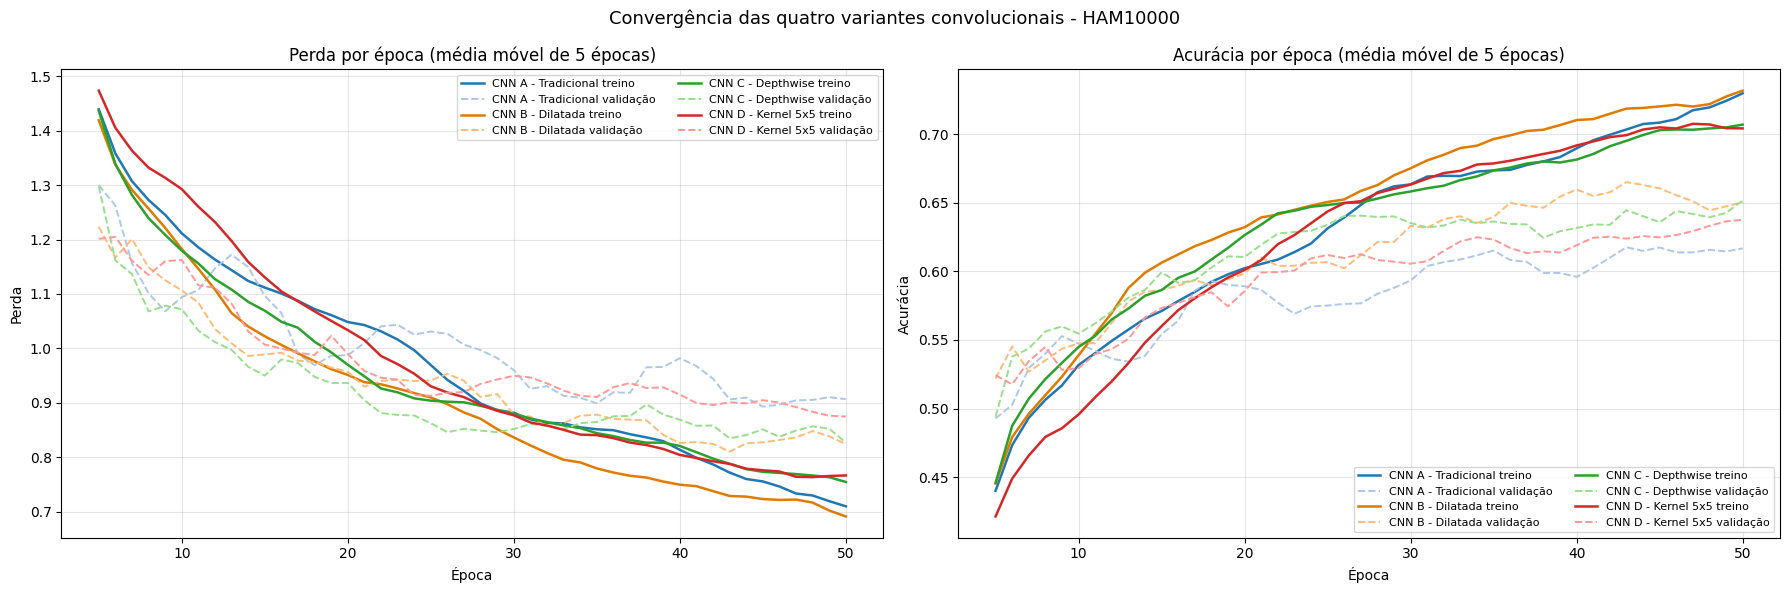

Gráfico de convergência salvo no W&B.


In [21]:
# Gráficos comparativos de convergência com média móvel de 5 épocas.
# Cada variante tem duas linhas: treino (mais escura) e validação (mais clara).
# A diferença entre as duas linhas sinaliza o grau de overfitting.
#.

import numpy as np

def media_movel(valores, janela=5):
    # Rotina que calcula a média móvel de uma lista de valores.
    return np.convolve(valores, np.ones(janela) / janela, mode="valid")

janela = min(5, CONFIG["epocas"])
epocas_mm = range(janela, CONFIG["epocas"] + 1)

estilos = [
    ("CNN A - Tradicional", historico_a, "#1f77b4", "#aec7e8"),
    ("CNN B - Dilatada",    historico_b, "#e07b00", "#ffbb78"),
    ("CNN C - Depthwise",   historico_c, "#2ca02c", "#98df8a"),
    ("CNN D - Kernel 5x5",  historico_d, "#d62728", "#ff9896"),
]

fig, eixos = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Convergência das quatro variantes convolucionais - HAM10000", fontsize=13)

for nome, hist, cor_treino, cor_val in estilos:
    mm_perda_treino    = media_movel(hist["perda_treino"],    janela)
    mm_perda_val       = media_movel(hist["perda_val"],       janela)
    mm_acuracia_treino = media_movel(hist["acuracia_treino"], janela)
    mm_acuracia_val    = media_movel(hist["acuracia_val"],    janela)

    eixos[0].plot(epocas_mm, mm_perda_treino, color=cor_treino,
                  linestyle="-",  linewidth=1.8, label="{} treino".format(nome))
    eixos[0].plot(epocas_mm, mm_perda_val,    color=cor_val,
                  linestyle="--", linewidth=1.4, label="{} validação".format(nome))

    eixos[1].plot(epocas_mm, mm_acuracia_treino, color=cor_treino,
                  linestyle="-",  linewidth=1.8, label="{} treino".format(nome))
    eixos[1].plot(epocas_mm, mm_acuracia_val,    color=cor_val,
                  linestyle="--", linewidth=1.4, label="{} validação".format(nome))

eixos[0].set_title("Perda por época (média móvel de {} épocas)".format(janela))
eixos[0].set_xlabel("Época")
eixos[0].set_ylabel("Perda")
eixos[0].legend(loc="upper right", fontsize=8, ncol=2)
eixos[0].grid(True, alpha=0.3)

eixos[1].set_title("Acurácia por época (média móvel de {} épocas)".format(janela))
eixos[1].set_xlabel("Época")
eixos[1].set_ylabel("Acurácia")
eixos[1].legend(loc="lower right", fontsize=8, ncol=2)
eixos[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("graficos_convergencia.png", dpi=150, bbox_inches="tight")
plt.show()
# Salvamento do gráfico de convergência no Weights and Biases.
if wandb.run is not None:
    wandb.finish()

run = wandb.init(
    project = CONFIG["projeto_wandb"],
    entity  = CONFIG["entidade_wandb"],
    name    = "graficos-convergencia",
    id      = "graficos-convergencia",
    resume  = "allow",
    config  = CONFIG,
)

wandb.log({"graficos_convergencia": wandb.Image("graficos_convergencia.png")})

run.finish()
print("Gráfico de convergência salvo no W&B.")

# Seção 5 - Avaliação no conjunto de teste

Esta seção avalia os modelos treinados sobre o conjunto de teste, que não foi utilizado em nenhuma etapa do treinamento ou validação. As métricas calculadas são acurácia, precisão, recall e F1-score por classe, além da matriz de confusão para cada variante.

## 5.1 Rotina de avaliação

A rotina de avaliação percorre o conjunto de teste, coleta as previsões de cada modelo e calcula as métricas consolidadas. O mesmo procedimento é aplicado aos três modelos.

In [22]:
def avaliar_modelo(modelo, loader_teste, nome_experimento):
    # Rotina que avalia um modelo treinado sobre o conjunto de teste.
    # Retorna as métricas consolidadas e os vetores de labels
    # verdadeiros e previstos para geração da matriz de confusão.
    modelo.eval()
    labels_verdadeiros = []
    labels_previstos   = []

    with torch.no_grad():
        for imagens, labels in loader_teste:
            imagens = imagens.to(device)
            saidas  = modelo(imagens)
            _, previstos = torch.max(saidas, 1)
            labels_verdadeiros.extend(labels.cpu().numpy())
            labels_previstos.extend(previstos.cpu().numpy())

    acuracia  = accuracy_score(labels_verdadeiros, labels_previstos)
    precisao  = precision_score(labels_verdadeiros, labels_previstos, average="macro", zero_division=0)
    recall    = recall_score(labels_verdadeiros, labels_previstos, average="macro", zero_division=0)
    f1        = f1_score(labels_verdadeiros, labels_previstos, average="macro", zero_division=0)
    matriz    = confusion_matrix(labels_verdadeiros, labels_previstos)

    print("Resultados - {}:".format(nome_experimento))
    print("  Acurácia  : {:.4f}".format(acuracia))
    print("  Precisão  : {:.4f}".format(precisao))
    print("  Recall    : {:.4f}".format(recall))
    print("  F1-score  : {:.4f}".format(f1))

    return {
        "nome"               : nome_experimento,
        "acuracia"           : acuracia,
        "precisao"           : precisao,
        "recall"             : recall,
        "f1"                 : f1,
        "matriz"             : matriz,
        "labels_verdadeiros" : labels_verdadeiros,
        "labels_previstos"   : labels_previstos,
    }

print("Rotina avaliar_modelo definida.")

Rotina avaliar_modelo definida.


## 5.2 Execução da avaliação

Os modelos são avaliados sobre o mesmo conjunto de teste com a rotina definida acima.

In [23]:
# Avaliação dos modelos sobre o conjunto de teste.
resultado_a = avaliar_modelo(modelo_a, loader_teste, CONFIG["nome_experimento_a"])
print()
resultado_b = avaliar_modelo(modelo_b, loader_teste, CONFIG["nome_experimento_b"])
print()
resultado_c = avaliar_modelo(modelo_c, loader_teste, CONFIG["nome_experimento_c"])
print()
resultado_d = avaliar_modelo(modelo_d, loader_teste, CONFIG["nome_experimento_d"])

Resultados - cnn-conv-tradicional:
  Acurácia  : 0.6108
  Precisão  : 0.5100
  Recall    : 0.6381
  F1-score  : 0.5269

Resultados - cnn-conv-dilatada:
  Acurácia  : 0.6707
  Precisão  : 0.5201
  Recall    : 0.6597
  F1-score  : 0.5582

Resultados - cnn-conv-depthwise:
  Acurácia  : 0.6647
  Precisão  : 0.5119
  Recall    : 0.6381
  F1-score  : 0.5429

Resultados - cnn-conv-kernel5x5:
  Acurácia  : 0.6161
  Precisão  : 0.4701
  Recall    : 0.6112
  F1-score  : 0.5010


## 5.3 Tabela comparativa de resultados

A tabela abaixo consolida as métricas dos experimentos para facilitar a comparação direta entre as variantes.

In [24]:
# Tabela comparativa com as métricas dos três experimentos no conjunto de teste.
dados_resultados = {
    "Modelo"    : ["CNN A - Tradicional", "CNN B - Dilatada", "CNN C - Depthwise", "CNN D - Kernel 5x5"],
    "Acuracia"  : [resultado_a["acuracia"],  resultado_b["acuracia"],  resultado_c["acuracia"],resultado_d["acuracia"]],
    "Precisao"  : [resultado_a["precisao"],  resultado_b["precisao"],  resultado_c["precisao"],resultado_d["precisao"]],
    "Recall"    : [resultado_a["recall"],    resultado_b["recall"],    resultado_c["recall"],resultado_d["recall"]],
    "F1-score"  : [resultado_a["f1"],        resultado_b["f1"],        resultado_c["f1"],resultado_d["f1"]],
}

df_resultados = pd.DataFrame(dados_resultados)
df_resultados["Acuracia"] = df_resultados["Acuracia"].map("{:.4f}".format)
df_resultados["Precisao"] = df_resultados["Precisao"].map("{:.4f}".format)
df_resultados["Recall"]   = df_resultados["Recall"].map("{:.4f}".format)
df_resultados["F1-score"] = df_resultados["F1-score"].map("{:.4f}".format)

print(df_resultados.to_string(index=False))

             Modelo Acuracia Precisao Recall F1-score
CNN A - Tradicional   0.6108   0.5100 0.6381   0.5269
   CNN B - Dilatada   0.6707   0.5201 0.6597   0.5582
  CNN C - Depthwise   0.6647   0.5119 0.6381   0.5429
 CNN D - Kernel 5x5   0.6161   0.4701 0.6112   0.5010


## 5.4 Matrizes de confusão

As matrizes de confusão mostram a distribuição das previsões por classe para cada variante. A diagonal principal representa os acertos. As células fora da diagonal revelam os padrões de confusão entre classes, especialmente relevantes dado o desbalanceamento do HAM10000.

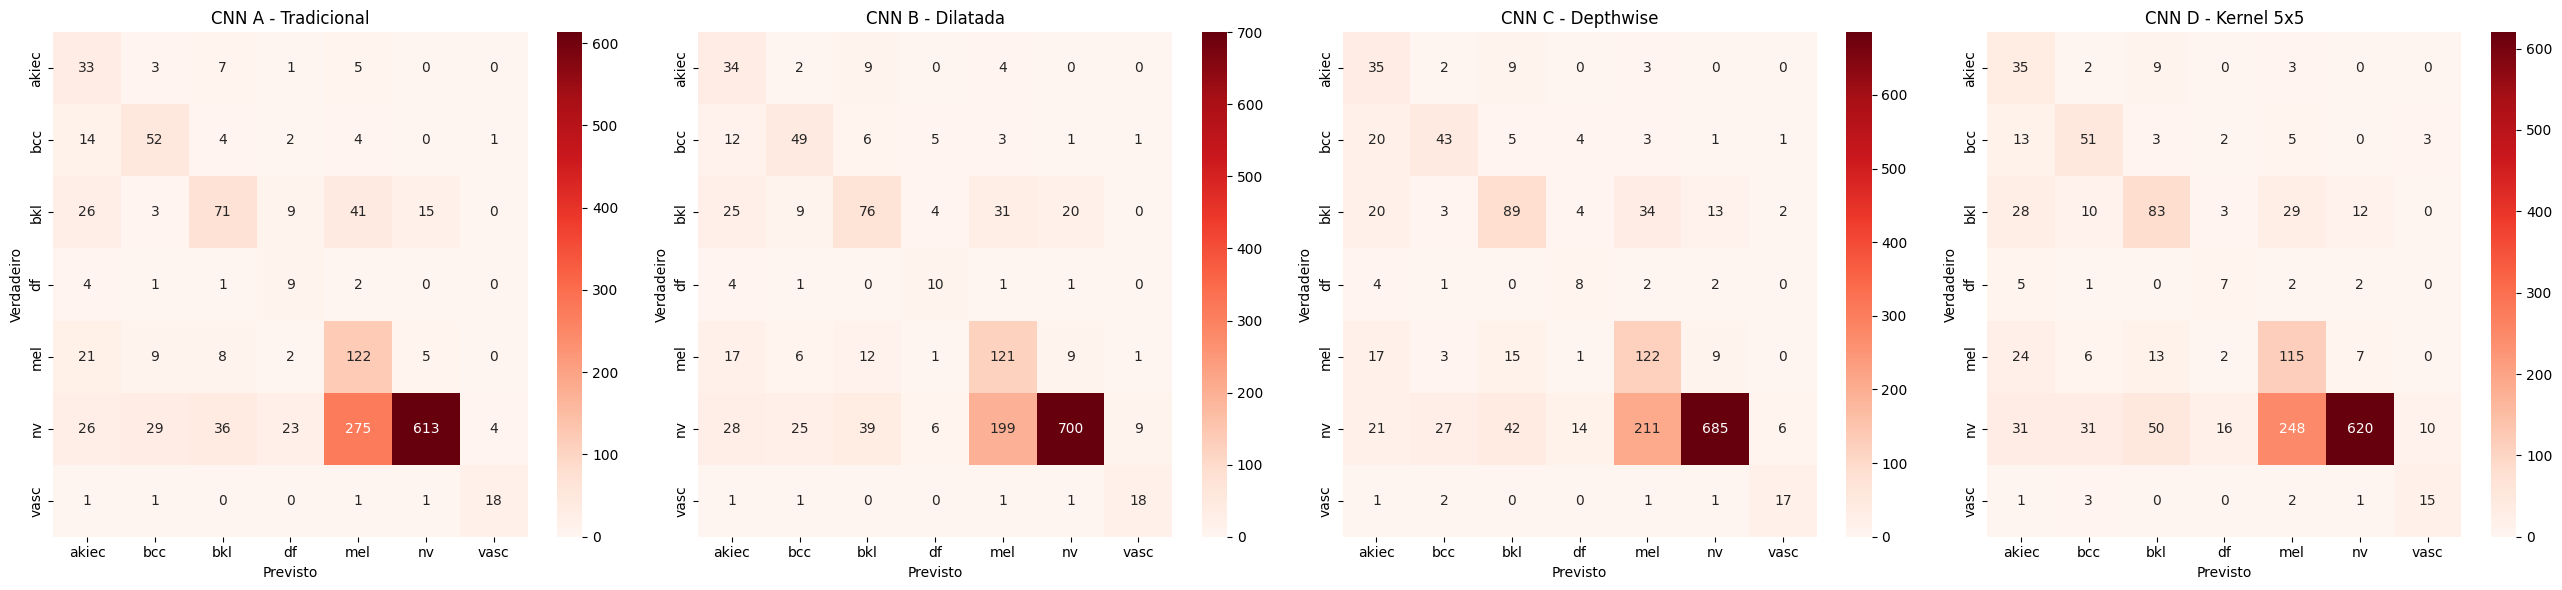

Matrizes de confusão geradas e salvas.


Matrizes de confusão salvas no W&B.


In [25]:
# Geração das matrizes de confusão para os experimentos.
fig, eixos = plt.subplots(1, 4, figsize=(26, 6))

nomes_experimentos = [
    ("CNN A - Tradicional", resultado_a["matriz"]),
    ("CNN B - Dilatada",    resultado_b["matriz"]),
    ("CNN C - Depthwise",   resultado_c["matriz"]),
    ("CNN D - Kernel 5x5",  resultado_d["matriz"]),
]

for eixo, (nome, matriz) in zip(eixos, nomes_experimentos):
    sns.heatmap(
        matriz,
        annot    = True,
        fmt      = "d",
        cmap     = "Reds",
        xticklabels = CLASSES,
        yticklabels = CLASSES,
        ax       = eixo
    )
    eixo.set_title(nome)
    eixo.set_xlabel("Previsto")
    eixo.set_ylabel("Verdadeiro")

plt.tight_layout()
plt.savefig("matrizes_confusao.png", dpi=300, bbox_inches="tight")
plt.show()
print("Matrizes de confusão geradas e salvas.")

# Salvamento das matrizes de confusão no Weights and Biases.
if wandb.run is not None:
    wandb.finish()

run = wandb.init(
    project = CONFIG["projeto_wandb"],
    entity  = CONFIG["entidade_wandb"],
    name    = "matrizes-confusao",
    id      = "matrizes-confusao",
    resume  = "allow",
    config  = CONFIG,
)

wandb.log({"matrizes_confusao": wandb.Image("matrizes_confusao.png")})

run.finish()
print("Matrizes de confusão salvas no W&B.")

## 5.5 Validação cruzada estratificada, CNN B e CNN C

Esta seção aplica validação cruzada estratificada com cinco folds nas duas variantes de maior interesse do experimento, a convolução dilatada e a convolução depthwise separável. O conjunto de teste original permanece fixo e reservado, sem participar da validação cruzada, para preservar uma avaliação final independente. O conjunto de treino e o conjunto de validação originais são unidos em um único pool, dividido em cinco folds estratificados pela classe. Em cada fold, quatro partes do pool servem de treino e uma parte serve de validação. Ao final, cada variante terá sido treinada cinco vezes, permitindo calcular a média e o desvio padrão das métricas, em vez de depender de uma única divisão aleatória dos dados.

In [26]:
from sklearn.model_selection import StratifiedKFold
import json
import numpy as np

# Rotina que une o treino e a validação originais em um único pool
# para a validação cruzada, mantendo o conjunto de teste intacto
# como avaliação final independente.
#.
df_pool_cv = pd.concat([df_treino, df_val], axis=0).reset_index(drop=True)

print("Tamanho do pool de validação cruzada, {}.".format(len(df_pool_cv)))
print("Tamanho do conjunto de teste, mantido fixo, {}.".format(len(df_teste)))

NUM_FOLDS = 5
CONFIG["num_folds"] = NUM_FOLDS

separador_kfold = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=CONFIG["semente"])
indices_por_fold = list(separador_kfold.split(df_pool_cv, df_pool_cv["label"]))

print("Validação cruzada configurada com {} folds estratificados.".format(NUM_FOLDS))

Tamanho do pool de validação cruzada, 8512.
Tamanho do conjunto de teste, mantido fixo, 1503.
Validação cruzada configurada com 5 folds estratificados.


### 5.5.1 Rotina de montagem dos loaders por fold

Cada fold precisa do seu próprio DataLoader de treino e de validação, com o WeightedRandomSampler recalculado apenas sobre a parte de treino daquele fold, já que a composição de classes muda um pouco de fold para fold.

In [27]:
def montar_loaders_fold(indice_treino, indice_val):
    # Rotina que constrói os DataLoaders de treino e validação de
    # um fold específico da validação cruzada, aplicando o
    # WeightedRandomSampler apenas na parte de treino do fold.
    #.
    df_treino_fold = df_pool_cv.loc[indice_treino].reset_index(drop=True)
    df_val_fold = df_pool_cv.loc[indice_val].reset_index(drop=True)

    dataset_treino_fold = HAM10000Dataset(df_treino_fold, transform=transform_treino)
    dataset_val_fold = HAM10000Dataset(df_val_fold, transform=transform_val_teste)

    contagens_fold = df_treino_fold["label"].value_counts().sort_index()
    pesos_por_classe_fold = 1.0 / contagens_fold.values.astype(float)
    pesos_por_amostra_fold = torch.tensor(
        [pesos_por_classe_fold[label] for label in df_treino_fold["label"].values],
        dtype=torch.float
    )

    sampler_fold = torch.utils.data.WeightedRandomSampler(
        weights=pesos_por_amostra_fold,
        num_samples=len(pesos_por_amostra_fold),
        replacement=True
    )

    loader_treino_fold = DataLoader(dataset_treino_fold, batch_size=CONFIG["batch_size"], sampler=sampler_fold, num_workers=2)
    loader_val_fold = DataLoader(dataset_val_fold, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

    return loader_treino_fold, loader_val_fold


print("Rotina montar_loaders_fold definida.")

Rotina montar_loaders_fold definida.


### 5.5.2 Rotina de registro do histórico e do gráfico por fold

Depois de treinar um fold, o histórico de perda e acurácia por época é salvo em um arquivo json e um gráfico de convergência é gerado. Os dois são registrados como artefatos no Weights and Biases, permitindo recuperar e reproduzir os gráficos depois, sem precisar treinar novamente.

In [28]:
def salvar_historico_e_grafico(historico, nome_execucao):
    # Rotina que salva o histórico de treinamento em um arquivo
    # json e gera um gráfico de convergência de perda e acurácia,
    # registrando ambos como artefatos no Weights and Biases para
    # permitir a reprodução posterior dos gráficos.
    #.
    caminho_json = "{}_historico.json".format(nome_execucao)
    with open(caminho_json, "w") as arquivo:
        json.dump(historico, arquivo)

    fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
    eixos[0].plot(historico["perda_treino"], label="Treino")
    eixos[0].plot(historico["perda_val"], label="Validação")
    eixos[0].set_title("Perda por época, {}.".format(nome_execucao))
    eixos[0].set_xlabel("Época")
    eixos[0].set_ylabel("Perda")
    eixos[0].legend()

    eixos[1].plot(historico["acuracia_treino"], label="Treino")
    eixos[1].plot(historico["acuracia_val"], label="Validação")
    eixos[1].set_title("Acurácia por época, {}.".format(nome_execucao))
    eixos[1].set_xlabel("Época")
    eixos[1].set_ylabel("Acurácia")
    eixos[1].legend()

    plt.tight_layout()
    caminho_imagem = "{}_convergencia.png".format(nome_execucao)
    plt.savefig(caminho_imagem, dpi=150, bbox_inches="tight")
    plt.show()

    run = wandb.init(
        project=CONFIG["projeto_wandb"],
        entity=CONFIG["entidade_wandb"],
        name="{}-artefatos".format(nome_execucao),
        id="{}-artefatos".format(nome_execucao),
        resume="allow",
        config=CONFIG,
    )
    wandb.log({"grafico_convergencia": wandb.Image(caminho_imagem)})

    artefato_historico = wandb.Artifact(name="{}-historico".format(nome_execucao), type="historico_treinamento")
    artefato_historico.add_file(caminho_json)
    run.log_artifact(artefato_historico)

    artefato_grafico = wandb.Artifact(name="{}-grafico".format(nome_execucao), type="grafico_convergencia")
    artefato_grafico.add_file(caminho_imagem)
    run.log_artifact(artefato_grafico)

    run.finish()

    print("Histórico e gráfico salvos e registrados no W e B, {}.".format(nome_execucao))


print("Rotina salvar_historico_e_grafico definida.")

Rotina salvar_historico_e_grafico definida.


### 5.5.3 Execução da validação cruzada

Este é o laço principal. Para cada uma das duas variantes, o modelo é retreinado do zero em cada um dos cinco folds, com semente diferente por fold para evitar inicializações idênticas. Antes de treinar um fold, o código consulta o Weights and Biases para verificar se aquela execução já foi concluída em uma sessão anterior. Se já foi, o histórico e o resultado de teste são recuperados diretamente, sem gastar tempo de GPU. Se ainda não foi, o treinamento acontece normalmente, e o resultado é salvo de um jeito que permite retomar de onde parou, caso a sessão seja interrompida antes do fim das dez execuções.

Rotinas de retomada definidas.
Iniciando validacao cruzada da variante dilatada.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 1 de 5, variante dilatada.


Época 1/50 - perda treino: 1.6458 - acurácia treino: 0.3557 - perda val: 1.6105 - acurácia val: 0.4216 - lr: 0.001000
Época 2/50 - perda treino: 1.4644 - acurácia treino: 0.4313 - perda val: 1.4060 - acurácia val: 0.4692 - lr: 0.001000
Época 3/50 - perda treino: 1.3661 - acurácia treino: 0.4670 - perda val: 1.0917 - acurácia val: 0.6101 - lr: 0.001000
Época 4/50 - perda treino: 1.3597 - acurácia treino: 0.4594 - perda val: 1.2062 - acurácia val: 0.5056 - lr: 0.001000
Época 5/50 - perda treino: 1.2983 - acurácia treino: 0.4955 - perda val: 1.0125 - acurácia val: 0.5901 - lr: 0.001000
Época 6/50 - perda treino: 1.2597 - acurácia treino: 0.5098 - perda val: 0.9125 - acurácia val: 0.5913 - lr: 0.001000
Época 7/50 - perda treino: 1.1983 - acurácia treino: 0.5272 - perda val: 0.9589 - acurácia val: 0.5661 - lr: 0.001000
Época 8/50 - perda treino: 1.1920 - acurácia treino: 0.5297 - perda val: 0.9392 - acurácia val: 0.6095 - lr: 0.001000
Época 9/50 - perda treino: 1.1621 - acurácia treino: 0.5

acuracia_treino,▁▂▃▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████████
acuracia_val,▁█▃▇▇█▄█▇▇▆▆▆▅▃▆█▆▆▆▆▇▇█▆▇▆▇▇▆▇▇▇▆▇▇▇▇▇▆
epoca,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,██████████▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
perda_treino,█▇▆▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
perda_val,█▆▃▄▂▁▁▃▂▂▁▂▂▂▂▂▂▁▂▂▂▂▁▁▁▂▁▂▁▁▁▁▁▁▂▁▂▁▂▁
acuracia_treino,0.71361
acuracia_val,0.58309
epoca,50
learning_rate,1e-05
perda_treino,0.74421


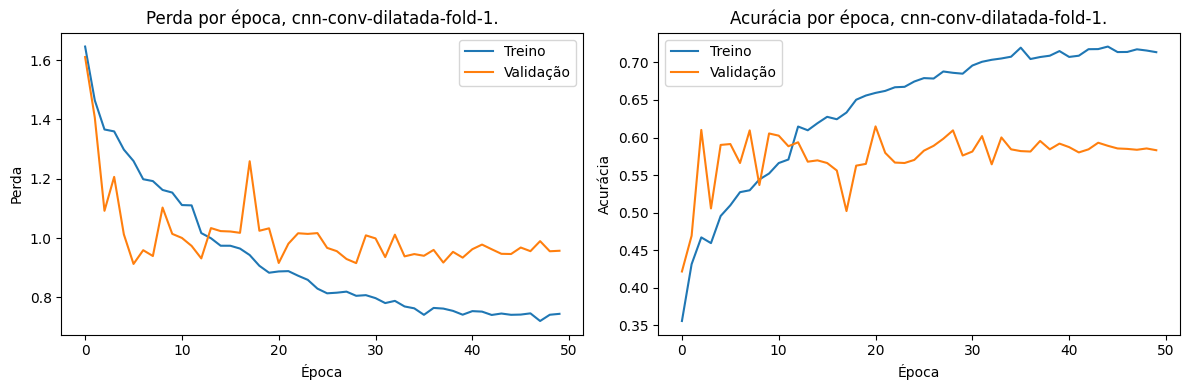

Histórico e gráfico salvos e registrados no W e B, cnn-conv-dilatada-fold-1.
Resultados - cnn-conv-dilatada-fold-1:
  Acurácia  : 0.5988
  Precisão  : 0.4673
  Recall    : 0.6139
  F1-score  : 0.4881


Resultado de teste salvo no Weights and Biases, cnn-conv-dilatada-fold-1.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 2 de 5, variante dilatada.


Época 1/50 - perda treino: 1.6798 - acurácia treino: 0.3388 - perda val: 1.5490 - acurácia val: 0.4005 - lr: 0.001000
Época 2/50 - perda treino: 1.4891 - acurácia treino: 0.4159 - perda val: 1.3823 - acurácia val: 0.4586 - lr: 0.001000
Época 3/50 - perda treino: 1.3757 - acurácia treino: 0.4641 - perda val: 1.2368 - acurácia val: 0.5308 - lr: 0.001000
Época 4/50 - perda treino: 1.3188 - acurácia treino: 0.4761 - perda val: 1.0606 - acurácia val: 0.5954 - lr: 0.001000
Época 5/50 - perda treino: 1.3020 - acurácia treino: 0.4996 - perda val: 1.0971 - acurácia val: 0.5473 - lr: 0.001000
Época 6/50 - perda treino: 1.2497 - acurácia treino: 0.5115 - perda val: 1.3034 - acurácia val: 0.4727 - lr: 0.001000
Época 7/50 - perda treino: 1.2373 - acurácia treino: 0.5123 - perda val: 0.9737 - acurácia val: 0.5984 - lr: 0.001000
Época 8/50 - perda treino: 1.1945 - acurácia treino: 0.5353 - perda val: 1.0437 - acurácia val: 0.5901 - lr: 0.001000
Época 9/50 - perda treino: 1.1578 - acurácia treino: 0.5

acuracia_treino,▁▂▃▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██▇████████████
acuracia_val,▁▃▅▇▅▇▆▅█▇▇▆▇▅▆▆▆▅▆▆▇▆▆▇▇▇▇▇▇▇▇▇█▇▇▇▇█▇▇
epoca,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,██████████████▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
perda_treino,█▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
perda_val,█▆▅▃▃▂▃▃▅▂▄▁▃▃▄▂▃▃▄▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▁▁▁
acuracia_treino,0.74637
acuracia_val,0.61362
epoca,50
learning_rate,3e-05
perda_treino,0.66175


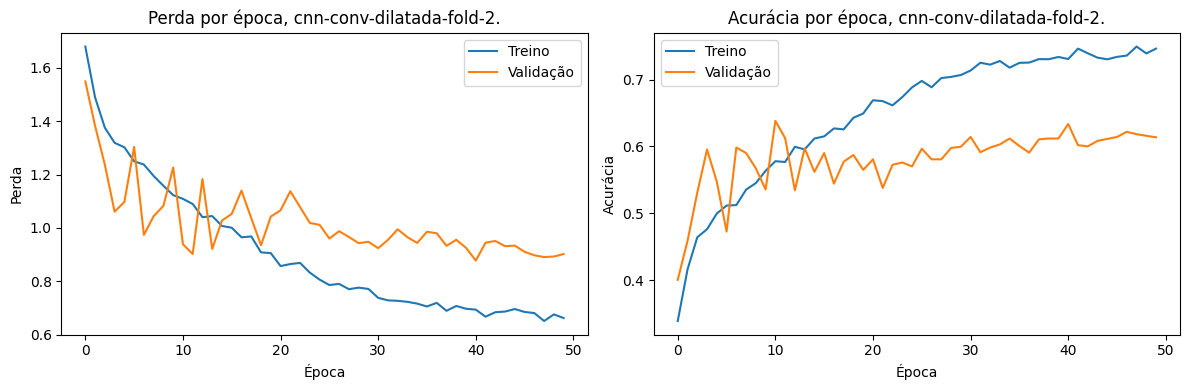

Histórico e gráfico salvos e registrados no W e B, cnn-conv-dilatada-fold-2.
Resultados - cnn-conv-dilatada-fold-2:
  Acurácia  : 0.6055
  Precisão  : 0.4667
  Recall    : 0.5866
  F1-score  : 0.4820


Resultado de teste salvo no Weights and Biases, cnn-conv-dilatada-fold-2.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 3 de 5, variante dilatada.


Época 1/50 - perda treino: 1.6449 - acurácia treino: 0.3523 - perda val: 1.5310 - acurácia val: 0.4142 - lr: 0.001000
Época 2/50 - perda treino: 1.4717 - acurácia treino: 0.4264 - perda val: 1.1318 - acurácia val: 0.5635 - lr: 0.001000
Época 3/50 - perda treino: 1.3953 - acurácia treino: 0.4568 - perda val: 1.2014 - acurácia val: 0.5065 - lr: 0.001000
Época 4/50 - perda treino: 1.3161 - acurácia treino: 0.4881 - perda val: 1.0861 - acurácia val: 0.5400 - lr: 0.001000
Época 5/50 - perda treino: 1.2847 - acurácia treino: 0.4950 - perda val: 1.0281 - acurácia val: 0.5846 - lr: 0.001000
Época 6/50 - perda treino: 1.2556 - acurácia treino: 0.5120 - perda val: 1.0231 - acurácia val: 0.5635 - lr: 0.001000
Época 7/50 - perda treino: 1.1885 - acurácia treino: 0.5443 - perda val: 1.2503 - acurácia val: 0.5006 - lr: 0.001000
Época 8/50 - perda treino: 1.1676 - acurácia treino: 0.5507 - perda val: 1.0886 - acurácia val: 0.5341 - lr: 0.001000
Época 9/50 - perda treino: 1.1440 - acurácia treino: 0.5

acuracia_treino,▁▂▃▃▄▄▅▅▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇████████████
acuracia_val,▁▆▄▅▆▅▆▇▆▅▅▇▆▆▆▇▇▇▇▆▆▇▆██▇▇▇▇▇▇▇██▇▇███▇
epoca,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,█████████▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
perda_treino,█▇▇▇▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
perda_val,█▄▄▃▂▅▃▄▃▃▁▃▁▃▃▃▂▂▂▃▃▂▂▁▂▂▂▁▂▂▂▂▁▂▁▁▁▂▁▁
acuracia_treino,0.73069
acuracia_val,0.60576
epoca,50
learning_rate,2e-05
perda_treino,0.7025


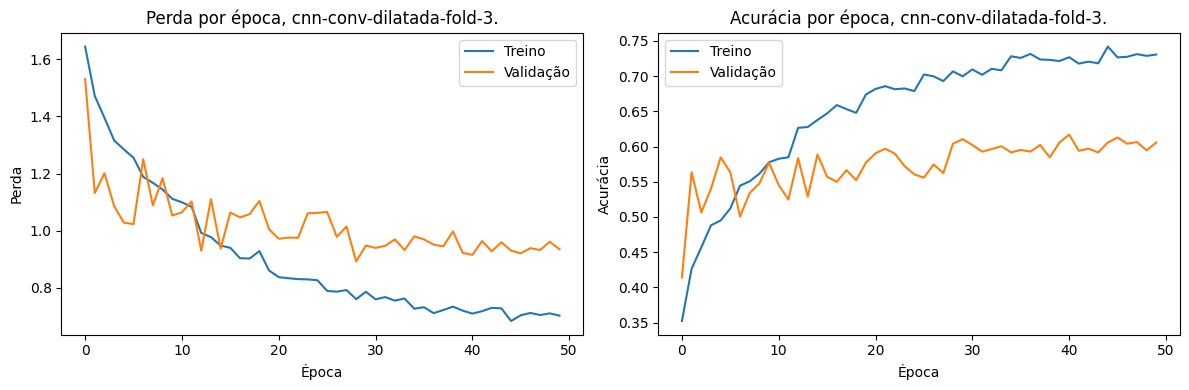

Histórico e gráfico salvos e registrados no W e B, cnn-conv-dilatada-fold-3.
Resultados - cnn-conv-dilatada-fold-3:
  Acurácia  : 0.5908
  Precisão  : 0.4674
  Recall    : 0.5788
  F1-score  : 0.4795


Resultado de teste salvo no Weights and Biases, cnn-conv-dilatada-fold-3.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 4 de 5, variante dilatada.


Época 1/50 - perda treino: 1.6632 - acurácia treino: 0.3414 - perda val: 1.2819 - acurácia val: 0.5006 - lr: 0.001000
Época 2/50 - perda treino: 1.4582 - acurácia treino: 0.4408 - perda val: 1.0072 - acurácia val: 0.6081 - lr: 0.001000
Época 3/50 - perda treino: 1.3744 - acurácia treino: 0.4692 - perda val: 1.1564 - acurácia val: 0.5335 - lr: 0.001000
Época 4/50 - perda treino: 1.2978 - acurácia treino: 0.4947 - perda val: 1.2173 - acurácia val: 0.5464 - lr: 0.001000
Época 5/50 - perda treino: 1.2762 - acurácia treino: 0.5059 - perda val: 1.1256 - acurácia val: 0.5405 - lr: 0.001000
Época 6/50 - perda treino: 1.2171 - acurácia treino: 0.5322 - perda val: 1.1552 - acurácia val: 0.5235 - lr: 0.001000
Época 7/50 - perda treino: 1.1660 - acurácia treino: 0.5419 - perda val: 0.9352 - acurácia val: 0.6204 - lr: 0.001000
Época 8/50 - perda treino: 1.1362 - acurácia treino: 0.5623 - perda val: 1.1019 - acurácia val: 0.5482 - lr: 0.001000
Época 9/50 - perda treino: 1.1272 - acurácia treino: 0.5

acuracia_treino,▁▃▃▄▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█▇▇▇█▇██████████
acuracia_val,▁▆▃▃▃▇▃▃▄▅▂▅▅▇▄▅▄▄▅█▇▆▇▆▆█▆▆▆▇█▇█▇▇▇▇▇▇█
epoca,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,██████████▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
perda_treino,█▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
perda_val,█▃▆▇▅▂▅▆▆▅▆▃▄▂▅▄▅▄▄▄▂▂▂▃▃▁▃▂▃▂▁▂▂▂▂▁▂▂▂▁
acuracia_treino,0.73025
acuracia_val,0.6416
epoca,50
learning_rate,3e-05
perda_treino,0.68944


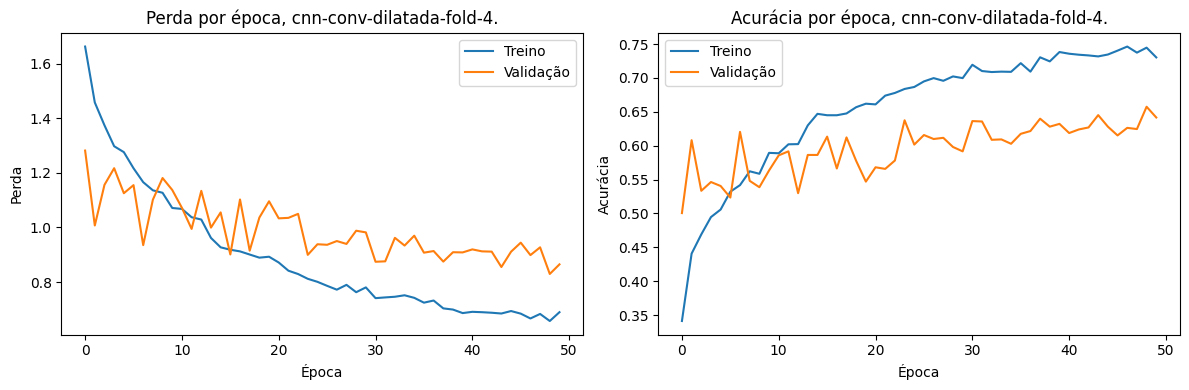

Histórico e gráfico salvos e registrados no W e B, cnn-conv-dilatada-fold-4.
Resultados - cnn-conv-dilatada-fold-4:
  Acurácia  : 0.6447
  Precisão  : 0.4940
  Recall    : 0.6539
  F1-score  : 0.5306


Resultado de teste salvo no Weights and Biases, cnn-conv-dilatada-fold-4.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 5 de 5, variante dilatada.


Época 1/50 - perda treino: 1.6440 - acurácia treino: 0.3640 - perda val: 1.4255 - acurácia val: 0.4806 - lr: 0.001000
Época 2/50 - perda treino: 1.4866 - acurácia treino: 0.4209 - perda val: 1.1976 - acurácia val: 0.5053 - lr: 0.001000
Época 3/50 - perda treino: 1.3757 - acurácia treino: 0.4720 - perda val: 1.3661 - acurácia val: 0.4671 - lr: 0.001000
Época 4/50 - perda treino: 1.3233 - acurácia treino: 0.4924 - perda val: 1.2403 - acurácia val: 0.5112 - lr: 0.001000
Época 5/50 - perda treino: 1.3191 - acurácia treino: 0.4871 - perda val: 1.1857 - acurácia val: 0.5188 - lr: 0.001000
Época 6/50 - perda treino: 1.2618 - acurácia treino: 0.5119 - perda val: 1.1356 - acurácia val: 0.5529 - lr: 0.001000
Época 7/50 - perda treino: 1.2418 - acurácia treino: 0.5173 - perda val: 1.0761 - acurácia val: 0.5793 - lr: 0.001000
Época 8/50 - perda treino: 1.2070 - acurácia treino: 0.5349 - perda val: 1.1879 - acurácia val: 0.5247 - lr: 0.001000
Época 9/50 - perda treino: 1.1607 - acurácia treino: 0.5

acuracia_treino,▁▂▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇███████
acuracia_val,▁▂▁▂▃▅▃▁▂▅▆▆▃▆▄▅▅▅▇▆▄▇▅▇▆▅▆▆▆▆█▆▇▆▇▇▇▇▇█
epoca,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,███████████████▄▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▂▁▁▁▁
perda_treino,█▇▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
perda_val,█▇▆▅▅▅█▆▂▅▂▅▃▄▃▃▂▂▂▂▁▂▂▂▂▂▂▂▃▂▁▂▁▃▁▁▂▁▁▁
acuracia_treino,0.77783
acuracia_val,0.66627
epoca,50
learning_rate,0.00013
perda_treino,0.58832


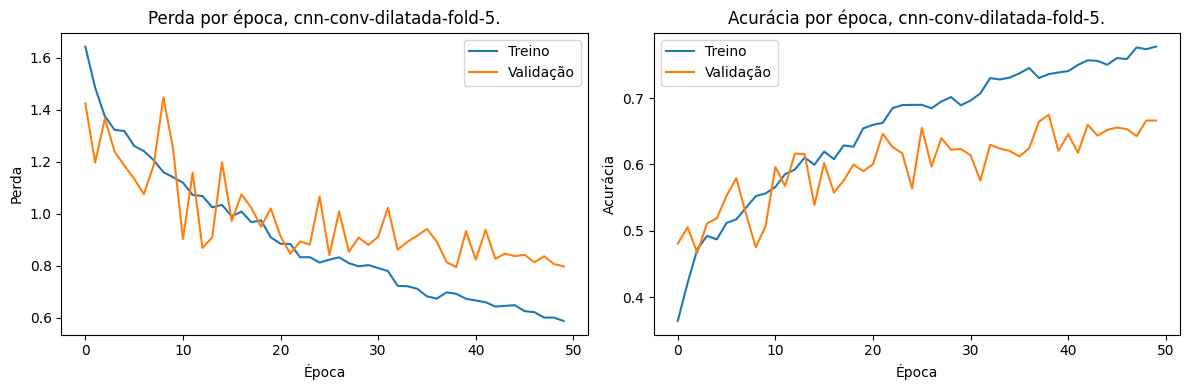

Histórico e gráfico salvos e registrados no W e B, cnn-conv-dilatada-fold-5.
Resultados - cnn-conv-dilatada-fold-5:
  Acurácia  : 0.6567
  Precisão  : 0.5275
  Recall    : 0.6483
  F1-score  : 0.5535


Resultado de teste salvo no Weights and Biases, cnn-conv-dilatada-fold-5.
Validacao cruzada da variante dilatada concluida.
Iniciando validacao cruzada da variante depthwise.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 1 de 5, variante depthwise.


Época 1/50 - perda treino: 1.7380 - acurácia treino: 0.3055 - perda val: 1.6854 - acurácia val: 0.3840 - lr: 0.001000
Época 2/50 - perda treino: 1.5482 - acurácia treino: 0.3970 - perda val: 1.2742 - acurácia val: 0.4692 - lr: 0.001000
Época 3/50 - perda treino: 1.4581 - acurácia treino: 0.4330 - perda val: 1.2766 - acurácia val: 0.5003 - lr: 0.001000
Época 4/50 - perda treino: 1.3836 - acurácia treino: 0.4597 - perda val: 1.0646 - acurácia val: 0.5291 - lr: 0.001000
Época 5/50 - perda treino: 1.2849 - acurácia treino: 0.5074 - perda val: 1.1717 - acurácia val: 0.5273 - lr: 0.001000
Época 6/50 - perda treino: 1.2641 - acurácia treino: 0.5126 - perda val: 1.0434 - acurácia val: 0.5573 - lr: 0.001000
Época 7/50 - perda treino: 1.2111 - acurácia treino: 0.5271 - perda val: 1.1267 - acurácia val: 0.5455 - lr: 0.001000
Época 8/50 - perda treino: 1.1920 - acurácia treino: 0.5413 - perda val: 1.3511 - acurácia val: 0.4921 - lr: 0.001000
Época 9/50 - perda treino: 1.1495 - acurácia treino: 0.5

acuracia_treino,▁▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████
acuracia_val,▁▃▄▅▅▅▄▅▆▆▆▅▆▆▅▅▆▅▅▇▆▇▇▆▇▆▆██▇▇▇▇█▇▇▇▇▇▇
epoca,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
learning_rate,█████████████████████████▄▄▄▄▄▂▂▂▂▂▁▁▁▁▁
perda_treino,█▇▆▆▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
perda_val,█▅▅▃▄▄▅▃▂▅▃▂▄▃▄▄▃▂▃▂▂▂▂▂▂▁▁▂▂▂▂▂▁▁▂▂▂▁▁▁
acuracia_treino,0.72448
acuracia_val,0.62772
epoca,50
learning_rate,0.00013
perda_treino,0.71628


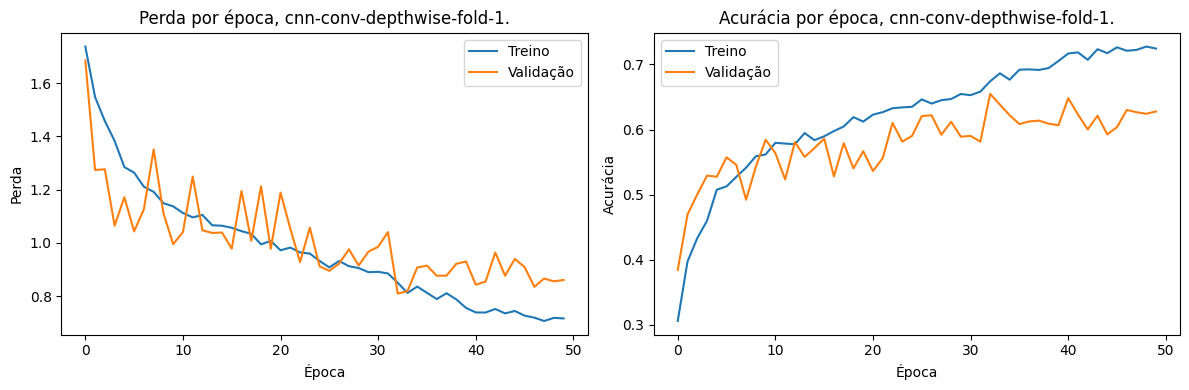

Histórico e gráfico salvos e registrados no W e B, cnn-conv-depthwise-fold-1.
Resultados - cnn-conv-depthwise-fold-1:
  Acurácia  : 0.6567
  Precisão  : 0.5319
  Recall    : 0.6867
  F1-score  : 0.5713


Resultado de teste salvo no Weights and Biases, cnn-conv-depthwise-fold-1.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 2 de 5, variante depthwise.


Época 1/50 - perda treino: 1.6937 - acurácia treino: 0.3319 - perda val: 1.3575 - acurácia val: 0.4774 - lr: 0.001000
Época 2/50 - perda treino: 1.4729 - acurácia treino: 0.4341 - perda val: 1.4719 - acurácia val: 0.4551 - lr: 0.001000
Época 3/50 - perda treino: 1.3913 - acurácia treino: 0.4613 - perda val: 1.3892 - acurácia val: 0.4651 - lr: 0.001000
Época 4/50 - perda treino: 1.2712 - acurácia treino: 0.5111 - perda val: 1.1897 - acurácia val: 0.5232 - lr: 0.001000
Época 5/50 - perda treino: 1.2212 - acurácia treino: 0.5336 - perda val: 1.2556 - acurácia val: 0.5120 - lr: 0.001000
Época 6/50 - perda treino: 1.1999 - acurácia treino: 0.5386 - perda val: 1.0952 - acurácia val: 0.5672 - lr: 0.001000
Época 7/50 - perda treino: 1.1548 - acurácia treino: 0.5643 - perda val: 0.9652 - acurácia val: 0.6083 - lr: 0.001000
Época 8/50 - perda treino: 1.1371 - acurácia treino: 0.5713 - perda val: 1.0596 - acurácia val: 0.5713 - lr: 0.001000
Época 9/50 - perda treino: 1.1220 - acurácia treino: 0.5

acuracia_treino,▁▂▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█▇▇▇█████████
acuracia_val,▂▁▁▃▃▆▅▆▅▆▅▄▅▆▄▇▆▆▆▆▇▆▆▆▆▇▇▆▇▇▇▇████▇▇▇▇
epoca,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,█████████████████▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
perda_treino,█▆▆▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
perda_val,▇█▇▅▆▂▃▃▃▂▃▄▃▃▂▂▂▃▂▃▁▂▂▂▂▂▁▁▁▂▁▁▁▁▁▂▁▂▁▂
acuracia_treino,0.72331
acuracia_val,0.63476
epoca,50
learning_rate,0.00025
perda_treino,0.73496


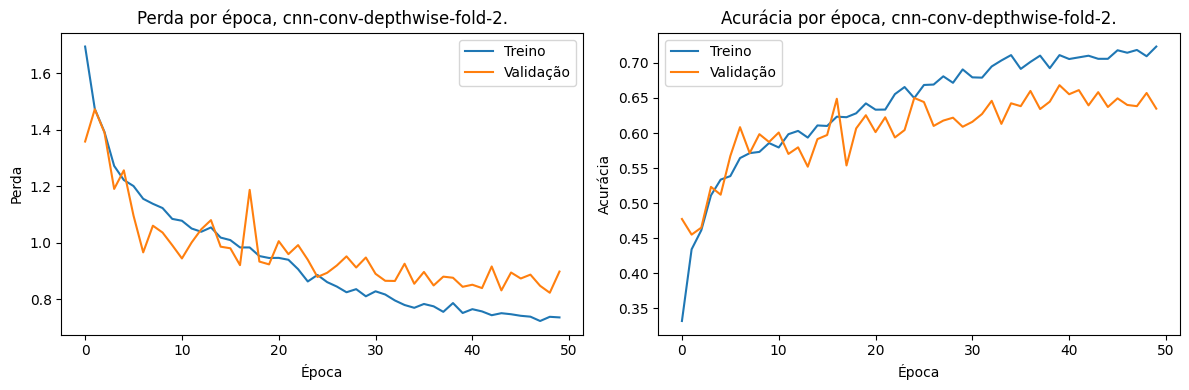

Histórico e gráfico salvos e registrados no W e B, cnn-conv-depthwise-fold-2.
Resultados - cnn-conv-depthwise-fold-2:
  Acurácia  : 0.6248
  Precisão  : 0.4776
  Recall    : 0.6595
  F1-score  : 0.5092


Resultado de teste salvo no Weights and Biases, cnn-conv-depthwise-fold-2.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 3 de 5, variante depthwise.


Época 1/50 - perda treino: 1.6837 - acurácia treino: 0.3433 - perda val: 1.3369 - acurácia val: 0.4659 - lr: 0.001000
Época 2/50 - perda treino: 1.4632 - acurácia treino: 0.4395 - perda val: 1.1190 - acurácia val: 0.5323 - lr: 0.001000
Época 3/50 - perda treino: 1.3836 - acurácia treino: 0.4683 - perda val: 1.3079 - acurácia val: 0.4771 - lr: 0.001000
Época 4/50 - perda treino: 1.3446 - acurácia treino: 0.4841 - perda val: 1.1143 - acurácia val: 0.5311 - lr: 0.001000
Época 5/50 - perda treino: 1.3100 - acurácia treino: 0.4896 - perda val: 1.1651 - acurácia val: 0.5129 - lr: 0.001000
Época 6/50 - perda treino: 1.2749 - acurácia treino: 0.5075 - perda val: 1.0990 - acurácia val: 0.5376 - lr: 0.001000
Época 7/50 - perda treino: 1.2306 - acurácia treino: 0.5266 - perda val: 1.1550 - acurácia val: 0.5194 - lr: 0.001000
Época 8/50 - perda treino: 1.1917 - acurácia treino: 0.5405 - perda val: 1.1420 - acurácia val: 0.5458 - lr: 0.001000
Época 9/50 - perda treino: 1.1669 - acurácia treino: 0.5

acuracia_treino,▁▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▆▇▆▇▇▇▇▇▇▇▇▇████████████
acuracia_val,▁▄▁▄▃▄▃▆▅▄▅▄▆▄▆▅▄▄▅▆▅▇▆▇▅▆▆▆▅▆▆▇█▇▇▇▇▆▇▇
epoca,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,████████████████████▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▁▁▁
perda_treino,█▆▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
perda_val,█▅█▅▆▅▅▆▄▄▄▅▄▃▅▂▄▃▄▃▃▂▃▂▃▃▂▂▃▂▃▂▁▂▂▂▂▃▂▁
acuracia_treino,0.72276
acuracia_val,0.61927
epoca,50
learning_rate,0.00013
perda_treino,0.72335


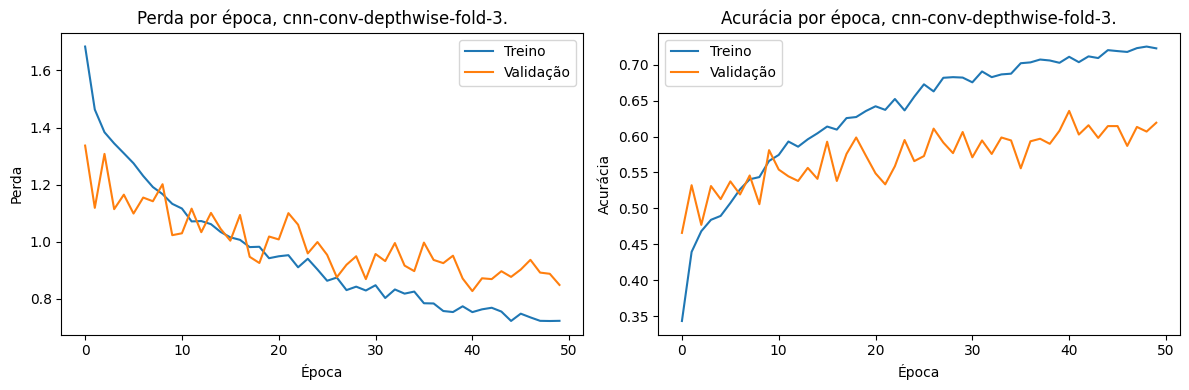

Histórico e gráfico salvos e registrados no W e B, cnn-conv-depthwise-fold-3.
Resultados - cnn-conv-depthwise-fold-3:
  Acurácia  : 0.6294
  Precisão  : 0.4576
  Recall    : 0.6410
  F1-score  : 0.5043


Resultado de teste salvo no Weights and Biases, cnn-conv-depthwise-fold-3.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 4 de 5, variante depthwise.


Época 1/50 - perda treino: 1.6669 - acurácia treino: 0.3398 - perda val: 1.2013 - acurácia val: 0.5135 - lr: 0.001000
Época 2/50 - perda treino: 1.4750 - acurácia treino: 0.4338 - perda val: 1.2221 - acurácia val: 0.5135 - lr: 0.001000
Época 3/50 - perda treino: 1.3676 - acurácia treino: 0.4831 - perda val: 1.1281 - acurácia val: 0.5311 - lr: 0.001000
Época 4/50 - perda treino: 1.3070 - acurácia treino: 0.4990 - perda val: 1.0231 - acurácia val: 0.5682 - lr: 0.001000
Época 5/50 - perda treino: 1.2350 - acurácia treino: 0.5256 - perda val: 1.2224 - acurácia val: 0.5071 - lr: 0.001000
Época 6/50 - perda treino: 1.2101 - acurácia treino: 0.5304 - perda val: 1.1181 - acurácia val: 0.5423 - lr: 0.001000
Época 7/50 - perda treino: 1.1492 - acurácia treino: 0.5593 - perda val: 1.0186 - acurácia val: 0.5640 - lr: 0.001000
Época 8/50 - perda treino: 1.1403 - acurácia treino: 0.5576 - perda val: 1.0080 - acurácia val: 0.5864 - lr: 0.001000
Época 9/50 - perda treino: 1.1332 - acurácia treino: 0.5

acuracia_treino,▁▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█▇████████████
acuracia_val,▁▁▄▁▂▄▄▅▄▅▇█▅▅▄▆▄▆▅▆▆█▆▅▆▆▆▆▇▇▇▇▆▇▇▇▇▇▇▇
epoca,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,██████████████████▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
perda_treino,█▇▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
perda_val,██▆▅█▅▄▄▄▅▄▅▂▁▄▆▂▃▅▃▃▃▁▃▄▂▃▃▂▂▂▂▂▃▂▂▂▂▂▁
acuracia_treino,0.71836
acuracia_val,0.65452
epoca,50
learning_rate,3e-05
perda_treino,0.73643


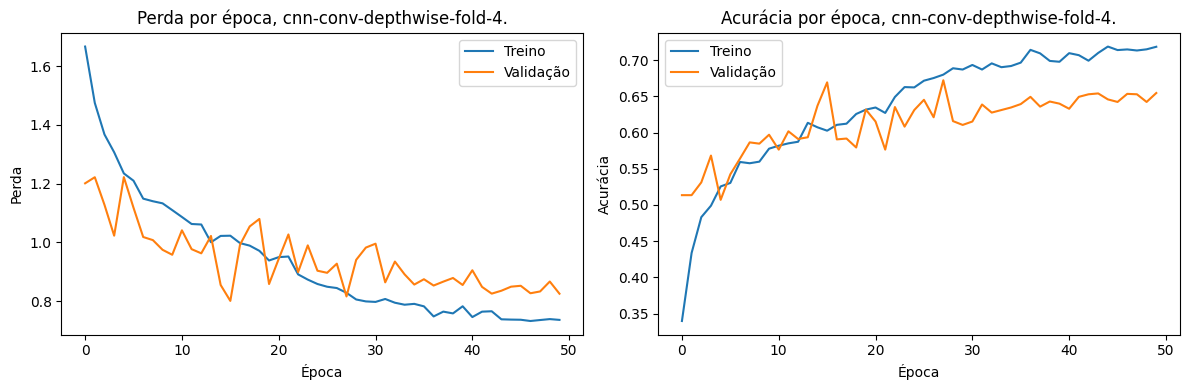

Histórico e gráfico salvos e registrados no W e B, cnn-conv-depthwise-fold-4.
Resultados - cnn-conv-depthwise-fold-4:
  Acurácia  : 0.6527
  Precisão  : 0.5264
  Recall    : 0.6366
  F1-score  : 0.5402


Resultado de teste salvo no Weights and Biases, cnn-conv-depthwise-fold-4.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Fold 5 de 5, variante depthwise.


Época 1/50 - perda treino: 1.7006 - acurácia treino: 0.3339 - perda val: 1.3741 - acurácia val: 0.4712 - lr: 0.001000
Época 2/50 - perda treino: 1.4744 - acurácia treino: 0.4360 - perda val: 1.3732 - acurácia val: 0.4371 - lr: 0.001000
Época 3/50 - perda treino: 1.4150 - acurácia treino: 0.4529 - perda val: 1.2992 - acurácia val: 0.5000 - lr: 0.001000
Época 4/50 - perda treino: 1.3576 - acurácia treino: 0.4696 - perda val: 1.1499 - acurácia val: 0.5306 - lr: 0.001000
Época 5/50 - perda treino: 1.3350 - acurácia treino: 0.4819 - perda val: 1.1035 - acurácia val: 0.5458 - lr: 0.001000
Época 6/50 - perda treino: 1.2874 - acurácia treino: 0.5016 - perda val: 1.2044 - acurácia val: 0.5306 - lr: 0.001000
Época 7/50 - perda treino: 1.2564 - acurácia treino: 0.5178 - perda val: 1.0913 - acurácia val: 0.5588 - lr: 0.001000
Época 8/50 - perda treino: 1.1830 - acurácia treino: 0.5408 - perda val: 0.9713 - acurácia val: 0.5905 - lr: 0.001000
Época 9/50 - perda treino: 1.1937 - acurácia treino: 0.5

acuracia_treino,▁▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
acuracia_val,▂▁▃▄▄▆▆▅▆▅▇▇▆▇▆▆█▆▇▇▇▇▇▇▇██▇▇▇▇▆█▇█▇▇▇▇▇
epoca,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,███████████▄▄▄▄▄▄▄▄▄▄▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
perda_treino,█▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
perda_val,██▇▅▅▃▄▄▄▃▄▂▂▃▂▂▃▂▃▂▂▂▂▂▂▃▁▁▂▂▂▃▂▂▂▂▂▂▂▂
acuracia_treino,0.70954
acuracia_val,0.62456
epoca,50
learning_rate,6e-05
perda_treino,0.7708


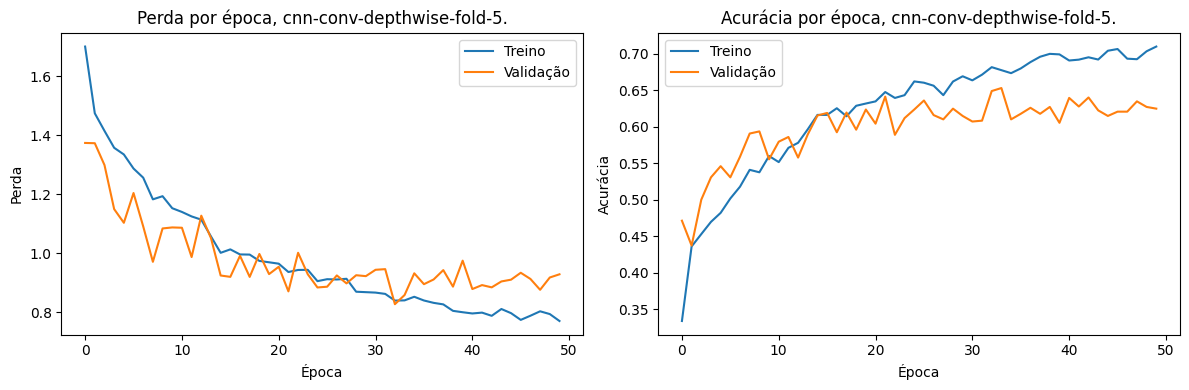

Histórico e gráfico salvos e registrados no W e B, cnn-conv-depthwise-fold-5.
Resultados - cnn-conv-depthwise-fold-5:
  Acurácia  : 0.6128
  Precisão  : 0.4622
  Recall    : 0.6347
  F1-score  : 0.4981


Resultado de teste salvo no Weights and Biases, cnn-conv-depthwise-fold-5.
Validacao cruzada da variante depthwise concluida.
Validacao cruzada concluida para as duas variantes.


In [29]:
import wandb
import json

api = wandb.Api()


def recuperar_historico(nome_execucao):
    # Rotina que baixa o artefato de historico salvo no Weights and
    # Biases para uma execucao ja concluida, permitindo reconstruir
    # os graficos de convergencia sem precisar treinar novamente.
    #.
    entidade = CONFIG["entidade_wandb"] or api.default_entity
    caminho_artefato = "{}/{}/{}-historico:latest".format(entidade, CONFIG["projeto_wandb"], nome_execucao)
    artefato = api.artifact(caminho_artefato, type="historico_treinamento")
    diretorio = artefato.download()
    caminho_json = "{}/{}_historico.json".format(diretorio, nome_execucao)
    with open(caminho_json) as arquivo:
        historico = json.load(arquivo)
    return historico


def salvar_resultado_teste(resultado, nome_execucao):
    # Rotina que salva as metricas escalares da avaliacao de teste
    # de um fold como um artefato json no Weights and Biases,
    # permitindo recuperar o resultado apos uma queda de sessao.
    #.
    metricas = {
        "acuracia": resultado["acuracia"],
        "precisao": resultado["precisao"],
        "recall": resultado["recall"],
        "f1": resultado["f1"],
    }
    caminho_json = "{}_resultado.json".format(nome_execucao)
    with open(caminho_json, "w") as arquivo:
        json.dump(metricas, arquivo)

    run = wandb.init(
        project=CONFIG["projeto_wandb"],
        entity=CONFIG["entidade_wandb"],
        name="{}-artefatos".format(nome_execucao),
        id="{}-artefatos".format(nome_execucao),
        resume="allow",
        config=CONFIG,
    )
    artefato_resultado = wandb.Artifact(name="{}-resultado".format(nome_execucao), type="resultado_teste")
    artefato_resultado.add_file(caminho_json)
    run.log_artifact(artefato_resultado)
    run.finish()

    print("Resultado de teste salvo no Weights and Biases, {}.".format(nome_execucao))


def recuperar_resultado_teste(nome_execucao):
    # Rotina que baixa o artefato com as metricas escalares de teste
    # de um fold ja concluido, permitindo recompor o resumo estatistico
    # da validacao cruzada sem treinar novamente.
    #.
    entidade = CONFIG["entidade_wandb"] or api.default_entity
    caminho_artefato = "{}/{}/{}-resultado:latest".format(entidade, CONFIG["projeto_wandb"], nome_execucao)
    artefato = api.artifact(caminho_artefato, type="resultado_teste")
    diretorio = artefato.download()
    caminho_json = "{}/{}_resultado.json".format(diretorio, nome_execucao)
    with open(caminho_json) as arquivo:
        metricas = json.load(arquivo)
    return metricas


def recuperar_fold_concluido(nome_execucao):
    # Rotina que tenta recuperar o historico e o resultado de teste
    # de um fold, retornando none nos dois quando qualquer um dos
    # dois artefatos nao existir, ou quando o historico recuperado
    # tiver um numero de epocas diferente do configurado atualmente.
    # Essa segunda checagem evita reaproveitar por engano um fold
    # que foi treinado com um valor antigo de epocas no CONFIG.
    #.
    try:
        historico = recuperar_historico(nome_execucao)
        resultado = recuperar_resultado_teste(nome_execucao)
    except Exception:
        return None, None

    if len(historico["perda_treino"]) != CONFIG["epocas"]:
        return None, None

    return historico, resultado


print("Rotinas de retomada definidas.")

VARIANTES_CV = ["dilatada", "depthwise"]
resultados_cv = {variante: [] for variante in VARIANTES_CV}
historicos_cv = {variante: [] for variante in VARIANTES_CV}

for variante in VARIANTES_CV:
    print("Iniciando validacao cruzada da variante {}.".format(variante))

    for numero_fold, (indice_treino, indice_val) in enumerate(indices_por_fold, start=1):
        nome_execucao = "cnn-conv-{}-fold-{}".format(variante, numero_fold)

        historico_fold, resultado_fold = recuperar_fold_concluido(nome_execucao)

        if historico_fold is not None and resultado_fold is not None:
            print("Fold {} de {}, variante {}, ja concluido, recuperando historico e resultado.".format(numero_fold, NUM_FOLDS, variante))
            historicos_cv[variante].append(historico_fold)
            resultados_cv[variante].append(resultado_fold)
            continue

        print("Fold {} de {}, variante {}.".format(numero_fold, NUM_FOLDS, variante))

        loader_treino_fold, loader_val_fold = montar_loaders_fold(indice_treino, indice_val)

        fixar_semente(CONFIG["semente"] + numero_fold)
        modelo_fold = CNNExperimental(tipo_conv=variante, num_classes=CONFIG["num_classes"]).to(device)

        historico_fold = treinar_modelo(modelo_fold, loader_treino_fold, loader_val_fold, nome_execucao)
        historicos_cv[variante].append(historico_fold)
        salvar_historico_e_grafico(historico_fold, nome_execucao)

        resultado_fold = avaliar_modelo(modelo_fold, loader_teste, nome_execucao)
        resultados_cv[variante].append(resultado_fold)
        salvar_resultado_teste(resultado_fold, nome_execucao)

        caminho_pesos_fold = "{}.pt".format(nome_execucao)
        torch.save(modelo_fold.state_dict(), caminho_pesos_fold)

    print("Validacao cruzada da variante {} concluida.".format(variante))

print("Validacao cruzada concluida para as duas variantes.")

### 5.5.4 Resumo estatístico entre os folds

Com os cinco resultados de teste de cada variante, calcula se a média e o desvio padrão de cada métrica. É esse desvio padrão que revela se a diferença entre a dilatada e a depthwise é consistente ou se está dentro da variação natural da divisão dos dados.

In [30]:
def calcular_media_desvio(resultados_variante, chave):
    # Rotina que calcula a média e o desvio padrão de uma métrica
    # específica entre os folds de uma variante.
    #.
    valores = [resultado[chave] for resultado in resultados_variante]
    media = float(np.mean(valores))
    desvio = float(np.std(valores))
    return media, desvio


linhas_resumo = []
for variante in VARIANTES_CV:
    linha = {"variante": variante}
    for metrica in ["acuracia", "precisao", "recall", "f1"]:
        media, desvio = calcular_media_desvio(resultados_cv[variante], metrica)
        linha["{}_media".format(metrica)] = media
        linha["{}_desvio".format(metrica)] = desvio
    linhas_resumo.append(linha)

df_resumo_cv = pd.DataFrame(linhas_resumo)
print(df_resumo_cv.to_string(index=False))

df_resumo_cv.to_csv("resumo_validacao_cruzada.csv", index=False)

run = wandb.init(
    project=CONFIG["projeto_wandb"],
    entity=CONFIG["entidade_wandb"],
    name="resumo-validacao-cruzada",
    id="resumo-validacao-cruzada",
    resume="allow",
    config=CONFIG,
)
artefato_resumo = wandb.Artifact(name="resumo-validacao-cruzada", type="resultados")
artefato_resumo.add_file("resumo_validacao_cruzada.csv")
run.log_artifact(artefato_resumo)
run.finish()

print("Resumo da validação cruzada salvo e registrado no W e B.")

 variante  acuracia_media  acuracia_desvio  precisao_media  precisao_desvio  recall_media  recall_desvio  f1_media  f1_desvio
 dilatada        0.619295         0.026330        0.484572         0.023852      0.616304       0.030762  0.506727   0.029860
depthwise        0.635263         0.016813        0.491144         0.031781      0.651713       0.019581  0.524607   0.027483


Resumo da validação cruzada salvo e registrado no W e B.


### 5.5.5 Gráfico de convergência agregado por variante

Em vez de olhar cada fold isoladamente, esta rotina calcula a média e o desvio padrão da curva de perda e da curva de acurácia de validação ao longo das épocas, entre os cinco folds, e desenha a faixa de desvio padrão ao redor da média.

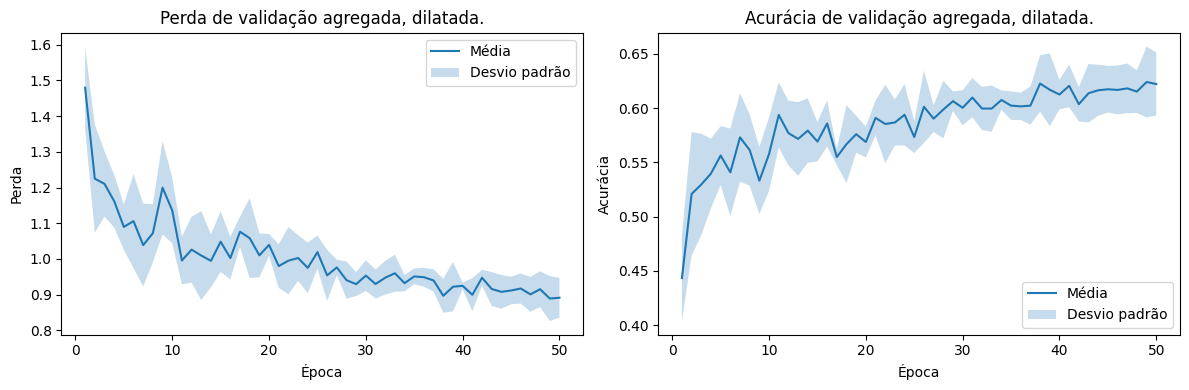

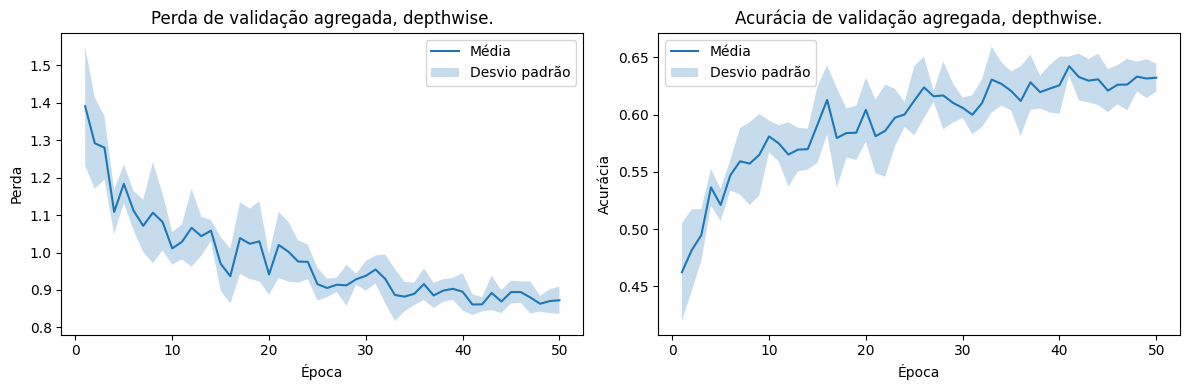

Gráficos de convergência agregada gerados e salvos no W e B.


In [31]:
def plotar_convergencia_agregada(historicos_variante, nome_variante):
    # Rotina que calcula a média e o desvio padrão das curvas de
    # perda e acurácia de validação entre os folds, permitindo
    # reproduzir um gráfico de convergência agregado da variante.
    #.
    perdas_val = np.array([h["perda_val"] for h in historicos_variante])
    acuracias_val = np.array([h["acuracia_val"] for h in historicos_variante])

    media_perda = perdas_val.mean(axis=0)
    desvio_perda = perdas_val.std(axis=0)
    media_acuracia = acuracias_val.mean(axis=0)
    desvio_acuracia = acuracias_val.std(axis=0)

    eixo_x_epocas = range(1, len(media_perda) + 1)

    fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
    eixos[0].plot(eixo_x_epocas, media_perda, label="Média")
    eixos[0].fill_between(eixo_x_epocas, media_perda - desvio_perda, media_perda + desvio_perda, alpha=0.25, label="Desvio padrão")
    eixos[0].set_title("Perda de validação agregada, {}.".format(nome_variante))
    eixos[0].set_xlabel("Época")
    eixos[0].set_ylabel("Perda")
    eixos[0].legend()

    eixos[1].plot(eixo_x_epocas, media_acuracia, label="Média")
    eixos[1].fill_between(eixo_x_epocas, media_acuracia - desvio_acuracia, media_acuracia + desvio_acuracia, alpha=0.25, label="Desvio padrão")
    eixos[1].set_title("Acurácia de validação agregada, {}.".format(nome_variante))
    eixos[1].set_xlabel("Época")
    eixos[1].set_ylabel("Acurácia")
    eixos[1].legend()

    plt.tight_layout()
    caminho_imagem = "convergencia_agregada_{}.png".format(nome_variante)
    plt.savefig(caminho_imagem, dpi=150, bbox_inches="tight")
    plt.show()

    return caminho_imagem


run = wandb.init(
    project=CONFIG["projeto_wandb"],
    entity=CONFIG["entidade_wandb"],
    name="convergencia-agregada",
    id="convergencia-agregada",
    resume="allow",
    config=CONFIG,
)

for variante in VARIANTES_CV:
    caminho_imagem_variante = plotar_convergencia_agregada(historicos_cv[variante], variante)
    wandb.log({"convergencia_agregada_{}".format(variante): wandb.Image(caminho_imagem_variante)})

run.finish()

print("Gráficos de convergência agregada gerados e salvos no W e B.")

# Seção 6 - Análise do aprendizado

Esta seção investiga o que cada variante convolucional aprendeu durante o treinamento. A análise é feita em três etapas. A primeira visualiza os mapas de ativação produzidos pela primeira e pela segunda camada convolucional de cada modelo. A segunda examina os filtros aprendidos pela primeira camada. A terceira aplica o método Grad-CAM para identificar as regiões da imagem que mais influenciaram a decisão de cada modelo.

## 6.1 Seleção de imagem para análise

Uma imagem do conjunto de teste é selecionada para servir de entrada nas três análises. A mesma imagem é utilizada nos três modelos para permitir comparação direta entre as variantes.

Imagem selecionada para análise.
Índice no dataframe de teste : 9.
Classe verdadeira            : mel.
Caminho                      : /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2/ISIC_0032192.jpg.
Formato do tensor de entrada : (1, 3, 224, 224).


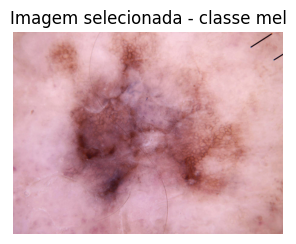

In [32]:
# Rotina que seleciona uma imagem do conjunto de teste para análise visual.
# Busca uma imagem da classe mel (melanoma) por ser relevante clinicamente.
idx_analise = df_teste[df_teste["dx"] == "mel"].index[0]
caminho_analise = df_teste.loc[idx_analise, "caminho"]
label_analise   = df_teste.loc[idx_analise, "dx"]

imagem_pil = Image.open(caminho_analise).convert("RGB")
imagem_tensor = transform_val_teste(imagem_pil).unsqueeze(0).to(device)

print("Imagem selecionada para análise.")
print("Índice no dataframe de teste : {}.".format(idx_analise))
print("Classe verdadeira            : {}.".format(label_analise))
print("Caminho                      : {}.".format(caminho_analise))
print("Formato do tensor de entrada : {}.".format(tuple(imagem_tensor.shape)))

plt.figure(figsize=(3, 3))
plt.imshow(imagem_pil)
plt.title("Imagem selecionada - classe {}".format(label_analise))
plt.axis("off")
plt.tight_layout()
plt.show()

## 6.2 Mapas de ativação

Os mapas de ativação mostram quais regiões da imagem cada filtro convolucional ativou após a operação de convolução seguida de ReLU. A visualização compara os mapas produzidos pela primeira e pela segunda camada convolucional das três variantes, permitindo observar como cada tipo de convolução extrai características em diferentes níveis de abstração.

In [33]:
def extrair_mapas_ativacao(modelo, imagem_tensor):
    # Rotina que extrai os mapas de ativação produzidos após
    # a primeira e a segunda camada convolucional do modelo,
    # incluindo a ativação ReLU aplicada em seguida.
    ativacoes = {}

    def gancho_conv1(modulo, entrada, saida):
        ativacoes["conv1"] = torch.relu(saida).detach().cpu()

    def gancho_conv2(modulo, entrada, saida):
        ativacoes["conv2"] = torch.relu(saida).detach().cpu()

    handle1 = modelo.conv1.register_forward_hook(gancho_conv1)
    handle2 = modelo.conv2.register_forward_hook(gancho_conv2)

    modelo.eval()
    with torch.no_grad():
        modelo(imagem_tensor)

    handle1.remove()
    handle2.remove()

    return ativacoes

print("Rotina extrair_mapas_ativacao definida.")

Rotina extrair_mapas_ativacao definida.


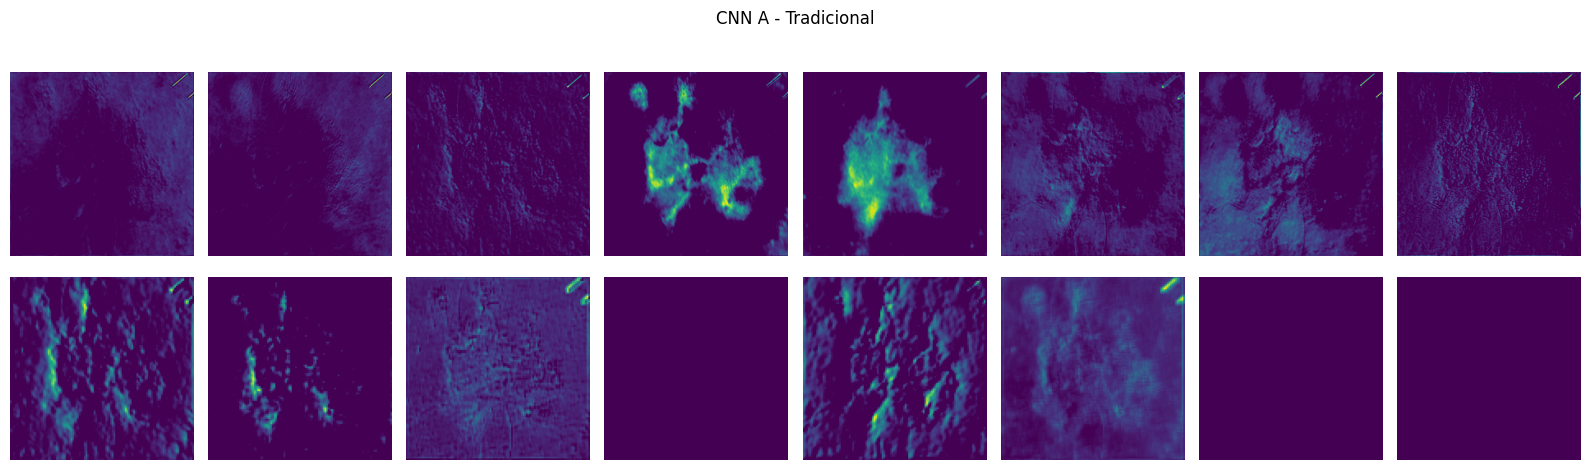

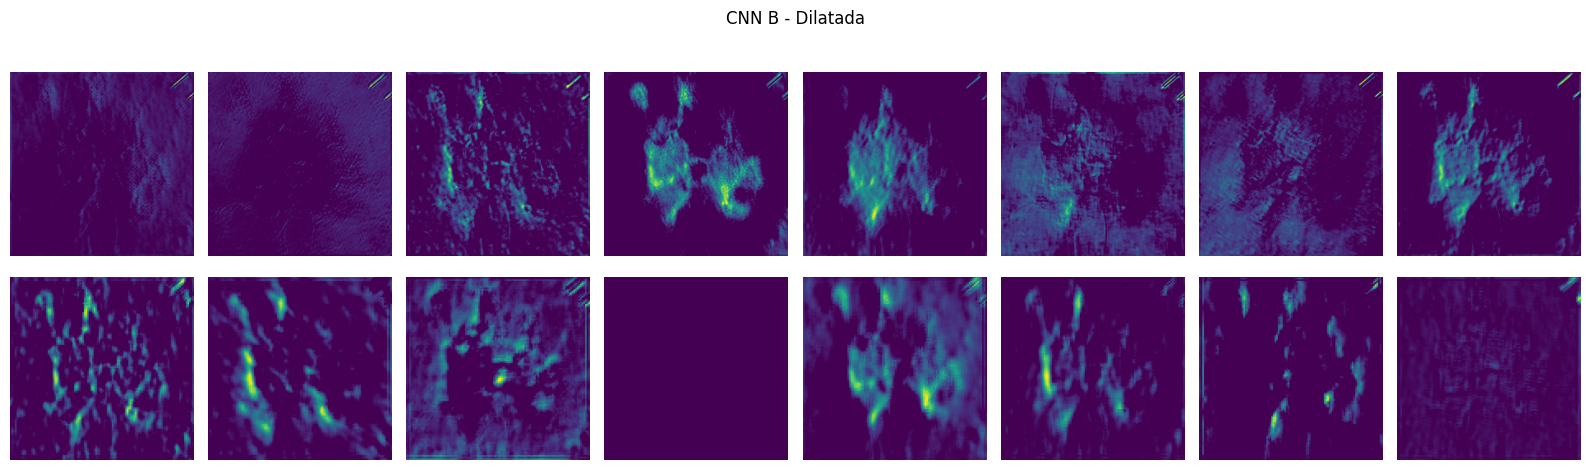

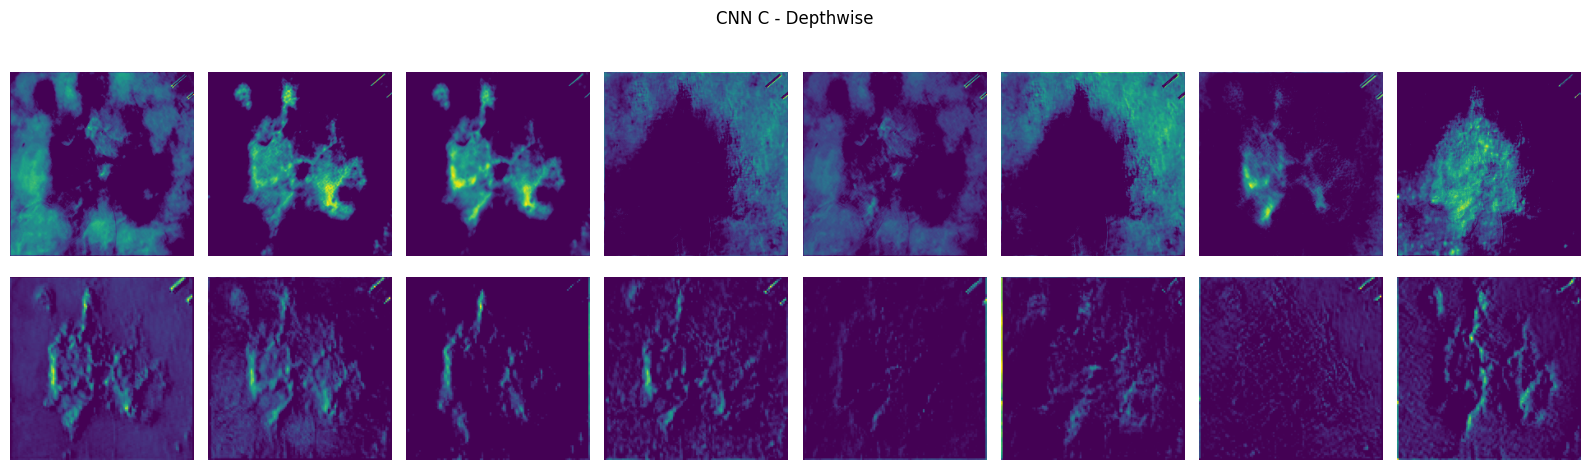

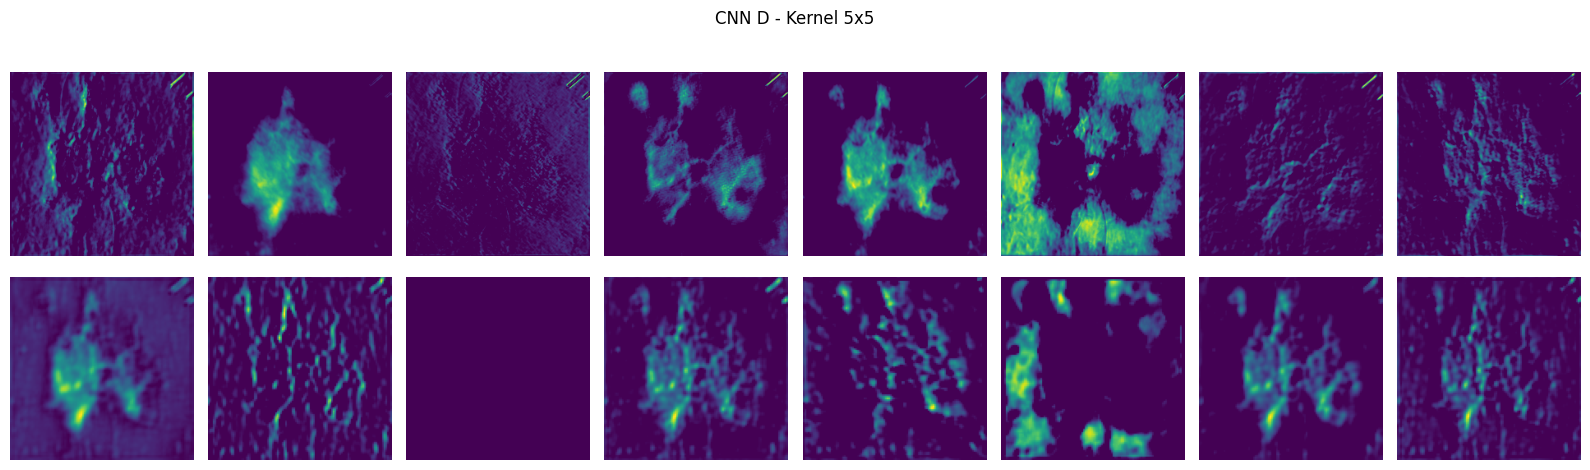

Mapas de ativação gerados para os modelos.


Mapas de ativação salvos no W&B.


In [34]:
# Visualização dos mapas de ativação.
def visualizar_mapas(ativacoes, titulo_modelo, num_mapas=8):
    # Rotina que plota os primeiros num_mapas mapas de ativação
    # produzidos pela primeira e pela segunda camada convolucional.
    fig, eixos = plt.subplots(2, num_mapas, figsize=(num_mapas * 2, 5))
    fig.suptitle(titulo_modelo, fontsize=12)

    for camada_idx, camada in enumerate(["conv1", "conv2"]):
        mapas = ativacoes[camada][0]
        for i in range(num_mapas):
            eixo = eixos[camada_idx, i]
            eixo.imshow(mapas[i].numpy(), cmap="viridis")
            eixo.axis("off")
            if i == 0:
                eixo.set_ylabel("Camada {}".format(camada_idx + 1), fontsize=9)

    plt.tight_layout()
    plt.savefig("mapas_{}.png".format(titulo_modelo.replace(" ", "_")), dpi=150, bbox_inches="tight")
    plt.show()

# Extração e visualização para os três modelos.
ativacoes_a = extrair_mapas_ativacao(modelo_a, imagem_tensor)
ativacoes_b = extrair_mapas_ativacao(modelo_b, imagem_tensor)
ativacoes_c = extrair_mapas_ativacao(modelo_c, imagem_tensor)
ativacoes_d = extrair_mapas_ativacao(modelo_d, imagem_tensor)

visualizar_mapas(ativacoes_a, "CNN A - Tradicional")
visualizar_mapas(ativacoes_b, "CNN B - Dilatada")
visualizar_mapas(ativacoes_c, "CNN C - Depthwise")
visualizar_mapas(ativacoes_d, "CNN D - Kernel 5x5")

print("Mapas de ativação gerados para os modelos.")

# Salvamento dos mapas de ativação no Weights and Biases.
if wandb.run is not None:
    wandb.finish()

run = wandb.init(
    project = CONFIG["projeto_wandb"],
    entity  = CONFIG["entidade_wandb"],
    name    = "mapas-ativacao",
    id      = "mapas-ativacao",
    resume  = "allow",
    config  = CONFIG,
)

arquivos_mapas = [
    "mapas_CNN_A_-_Tradicional.png",
    "mapas_CNN_B_-_Dilatada.png",
    "mapas_CNN_C_-_Depthwise.png",
    "mapas_CNN_D_-_Kernel_5x5.png",
]

wandb.log({
    nome.replace(".png", "").replace("-", "_") : wandb.Image(nome)
    for nome in arquivos_mapas
    if os.path.exists(nome)
})

run.finish()
print("Mapas de ativação salvos no W&B.")

## 6.3 Visualização dos filtros

Os filtros da primeira camada convolucional representam os padrões elementares que o modelo detectou na imagem de entrada. Filtros com pesos organizados podem indicar a linha de aprendizado do modelo, ou seja, borda, textura ou gradiente.

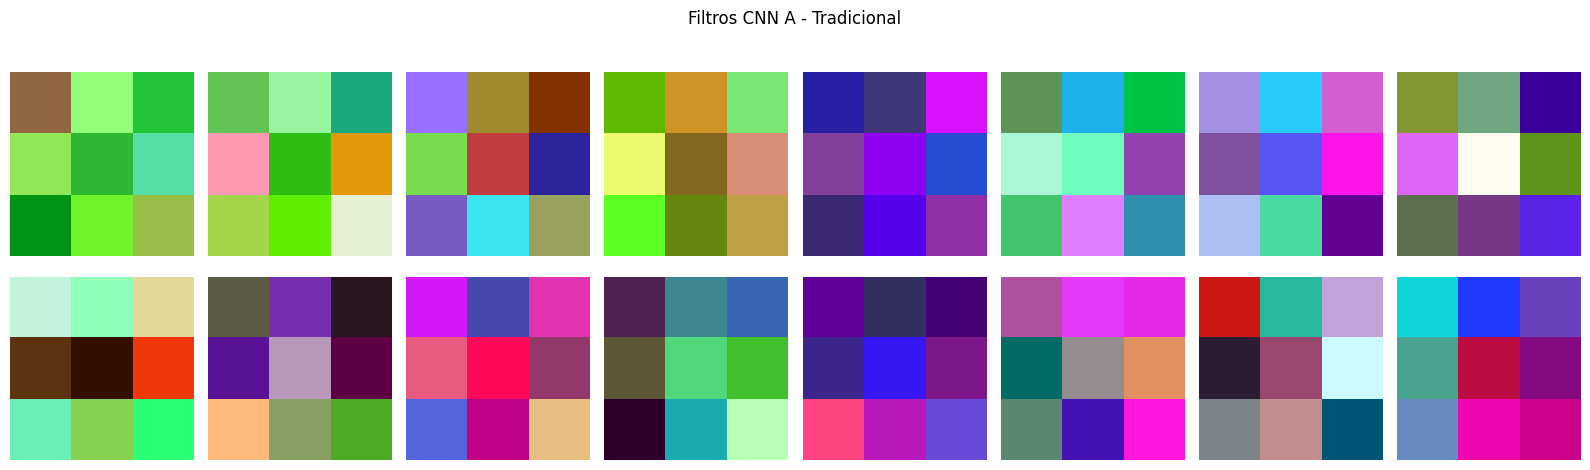

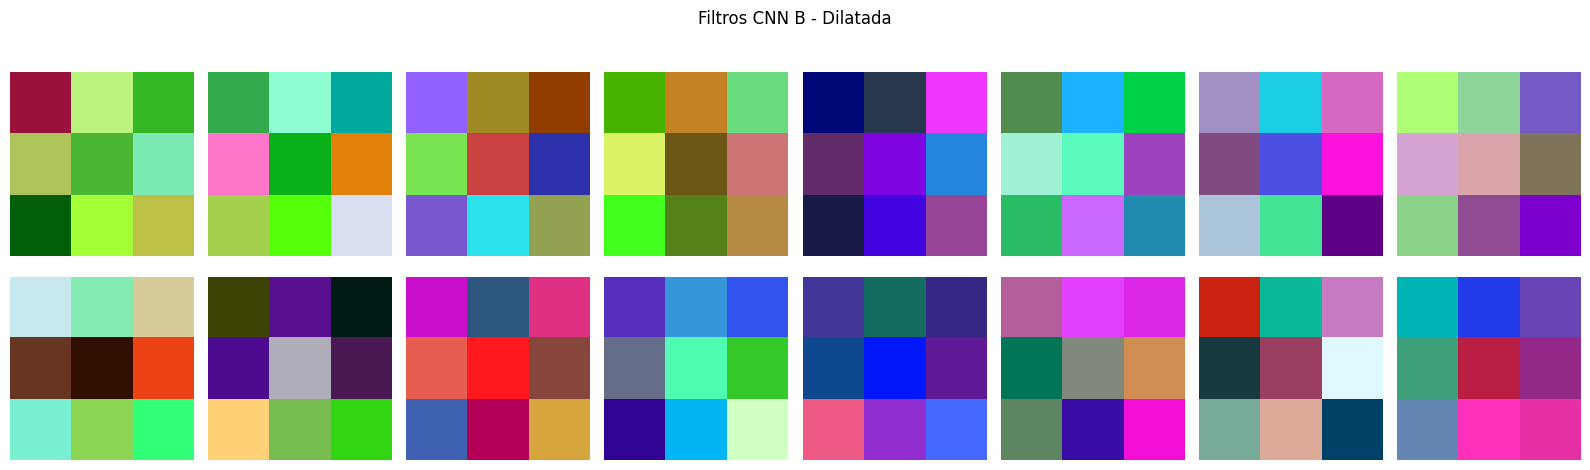

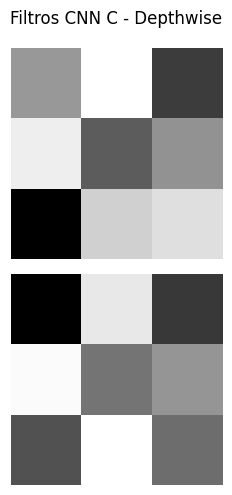

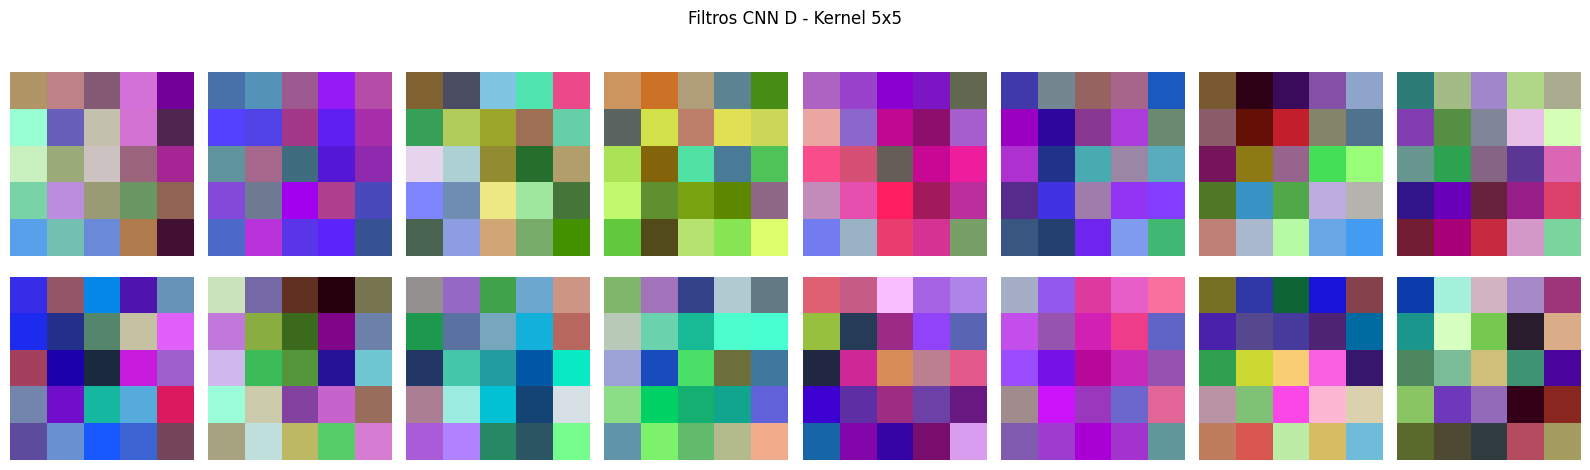

Filtros visualizados para os modelos.


Filtros aprendidos salvos no W&B.


In [35]:
def visualizar_filtros(modelo, titulo_modelo, num_filtros=16):
    # Rotina que visualiza os pesos dos primeiros num_filtros filtros
    # da primeira camada convolucional do modelo.
    # Cada filtro tem 3 canais RGB e é exibido como imagem normalizada.
    if hasattr(modelo.conv1, "conv"):
        pesos = modelo.conv1.conv.weight.detach().cpu()
    elif hasattr(modelo.conv1, "depthwise"):
        pesos = modelo.conv1.depthwise.weight.detach().cpu()
    else:
        print("Estrutura de pesos não reconhecida para {}.".format(titulo_modelo))
        return

    num_filtros = min(num_filtros, pesos.shape[0])
    fig, eixos = plt.subplots(2, num_filtros // 2, figsize=(num_filtros, 5))
    fig.suptitle("Filtros {}".format(titulo_modelo), fontsize=12)

    for i, eixo in enumerate(eixos.flat):
        if i >= num_filtros:
            eixo.axis("off")
            continue
        filtro = pesos[i]
        if filtro.shape[0] == 3:
            filtro_vis = filtro.permute(1, 2, 0).numpy()
        else:
            filtro_vis = filtro[0].numpy()
        filtro_vis = (filtro_vis - filtro_vis.min()) / (filtro_vis.max() - filtro_vis.min() + 1e-8)
        eixo.imshow(filtro_vis, cmap="gray" if filtro_vis.ndim == 2 else None)
        eixo.axis("off")

    plt.tight_layout()
    plt.savefig("filtros_{}.png".format(titulo_modelo.replace(" ", "_")), dpi=150, bbox_inches="tight")
    plt.show()

visualizar_filtros(modelo_a, "CNN A - Tradicional")
visualizar_filtros(modelo_b, "CNN B - Dilatada")
visualizar_filtros(modelo_c, "CNN C - Depthwise")
visualizar_filtros(modelo_d, "CNN D - Kernel 5x5")

print("Filtros visualizados para os modelos.")

# Salvamento dos filtros no Weights and Biases.
if wandb.run is not None:
    wandb.finish()

run = wandb.init(
    project = CONFIG["projeto_wandb"],
    entity  = CONFIG["entidade_wandb"],
    name    = "filtros",
    id      = "filtros",
    resume  = "allow",
    config  = CONFIG,
)

arquivos_filtros = [
    "filtros_CNN_A_-_Tradicional.png",
    "filtros_CNN_B_-_Dilatada.png",
    "filtros_CNN_C_-_Depthwise.png",
    "filtros_CNN_D_-_Kernel_5x5.png",
]

wandb.log({
    nome.replace(".png", "").replace("-", "_") : wandb.Image(nome)
    for nome in arquivos_filtros
    if os.path.exists(nome)
})

run.finish()
print("Filtros aprendidos salvos no W&B.")

## 6.4 Grad-CAM

O método Grad-CAM calcula o gradiente da classe prevista em relação aos mapas de ativação da última camada convolucional. Esses gradientes indicam quais regiões do mapa de ativação foram mais relevantes para a decisão do modelo. O resultado é um mapa de calor sobreposto à imagem original que destaca as regiões que mais influenciaram a classificação.

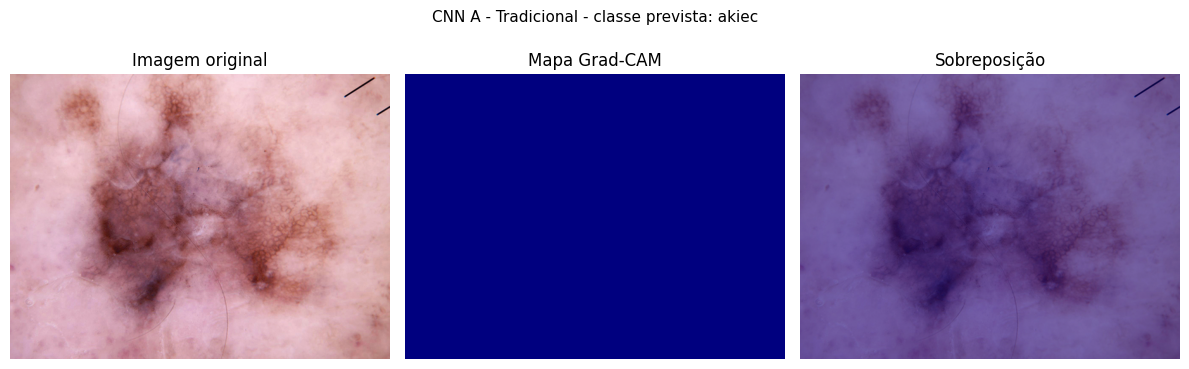

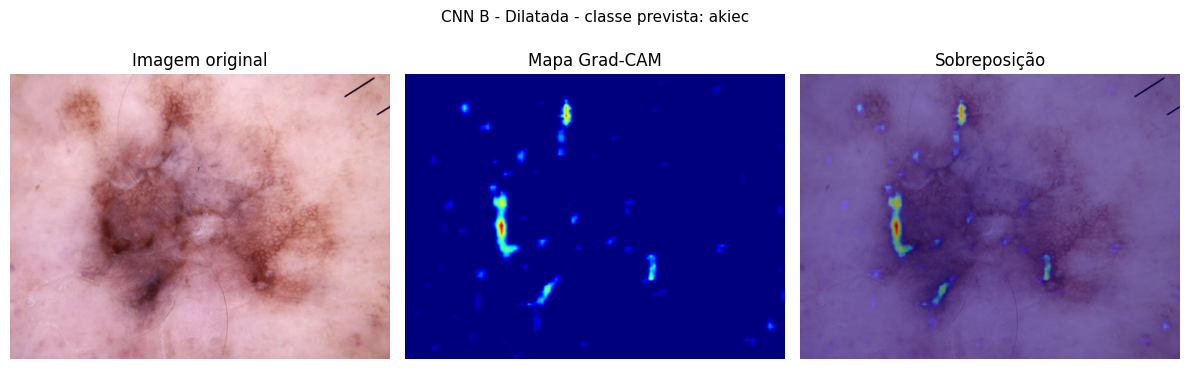

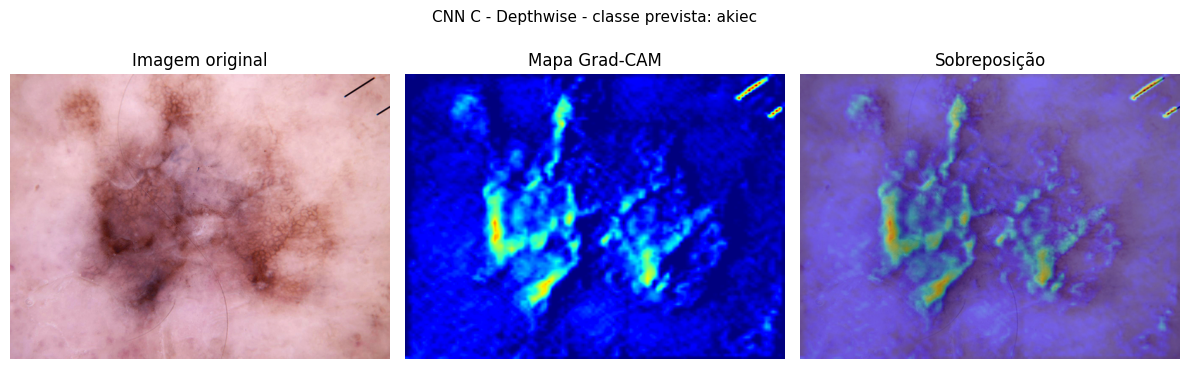

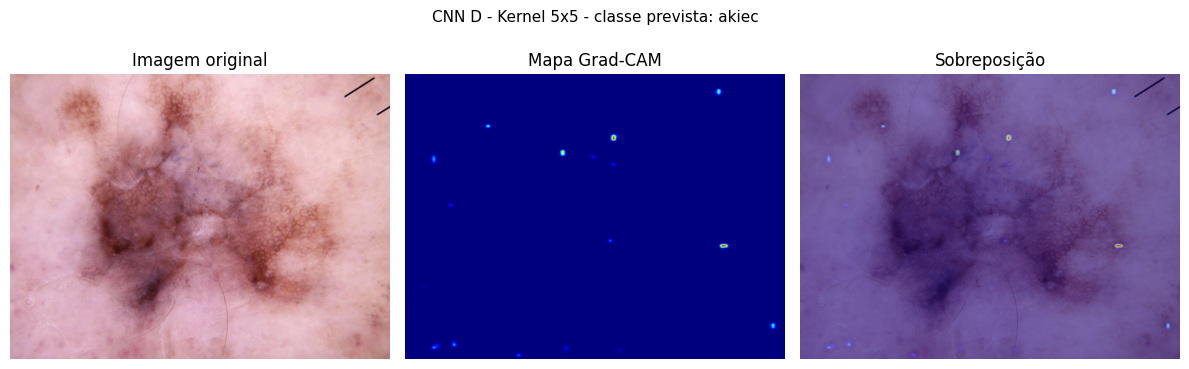

Grad-CAM gerado para os modelos.


Mapas Grad-CAM salvos no W&B.


In [36]:
def calcular_gradcam(modelo, imagem_tensor):
    # Rotina que calcula o mapa Grad-CAM para a classe prevista
    # a partir da segunda camada convolucional do modelo.
    ativacao_conv2 = {}
    gradiente_conv2 = {}

    def gancho_forward(modulo, entrada, saida):
        ativacao_conv2["valor"] = saida

    def gancho_backward(modulo, grad_entrada, grad_saida):
        gradiente_conv2["valor"] = grad_saida[0]

    handle_f = modelo.conv2.register_forward_hook(gancho_forward)
    handle_b = modelo.conv2.register_full_backward_hook(gancho_backward)

    modelo.eval()
    saida = modelo(imagem_tensor)
    classe_prevista = saida.argmax(dim=1).item()

    modelo.zero_grad()
    saida[0, classe_prevista].backward()

    handle_f.remove()
    handle_b.remove()

    gradientes  = gradiente_conv2["valor"].detach().cpu()[0]
    ativacoes   = ativacao_conv2["valor"].detach().cpu()[0]
    pesos_canal = gradientes.mean(dim=(1, 2))

    mapa_cam = torch.zeros(ativacoes.shape[1:])
    for i, peso in enumerate(pesos_canal):
        mapa_cam += peso * ativacoes[i]

    mapa_cam = torch.relu(mapa_cam).numpy()
    mapa_cam = (mapa_cam - mapa_cam.min()) / (mapa_cam.max() - mapa_cam.min() + 1e-8)

    return mapa_cam, classe_prevista


def visualizar_gradcam(modelo, imagem_tensor, imagem_pil, titulo_modelo):
    # Rotina que sobrepõe o mapa Grad-CAM à imagem original
    # e exibe o resultado com a classe prevista pelo modelo.
    import numpy as np
    from PIL import Image as PILImage

    mapa_cam, classe_prevista = calcular_gradcam(modelo, imagem_tensor)

    mapa_redim = np.array(
        PILImage.fromarray((mapa_cam * 255).astype(np.uint8)).resize(
            imagem_pil.size, PILImage.BILINEAR
        )
    ) / 255.0

    imagem_np = np.array(imagem_pil) / 255.0

    fig, eixos = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle("{} - classe prevista: {}".format(titulo_modelo, idx_para_classe[classe_prevista]), fontsize=11)

    eixos[0].imshow(imagem_np)
    eixos[0].set_title("Imagem original")
    eixos[0].axis("off")

    eixos[1].imshow(mapa_redim, cmap="jet")
    eixos[1].set_title("Mapa Grad-CAM")
    eixos[1].axis("off")

    eixos[2].imshow(imagem_np)
    eixos[2].imshow(mapa_redim, cmap="jet", alpha=0.5)
    eixos[2].set_title("Sobreposição")
    eixos[2].axis("off")

    plt.tight_layout()
    plt.savefig("gradcam_{}.png".format(titulo_modelo.replace(" ", "_")), dpi=150, bbox_inches="tight")
    plt.show()

visualizar_gradcam(modelo_a, imagem_tensor, imagem_pil, "CNN A - Tradicional")
visualizar_gradcam(modelo_b, imagem_tensor, imagem_pil, "CNN B - Dilatada")
visualizar_gradcam(modelo_c, imagem_tensor, imagem_pil, "CNN C - Depthwise")
visualizar_gradcam(modelo_d, imagem_tensor, imagem_pil, "CNN D - Kernel 5x5")

print("Grad-CAM gerado para os modelos.")

# Salvamento dos mapas Grad-CAM no Weights and Biases.
if wandb.run is not None:
    wandb.finish()

run = wandb.init(
    project = CONFIG["projeto_wandb"],
    entity  = CONFIG["entidade_wandb"],
    name    = "grad-cam",
    id      = "grad-cam",
    resume  = "allow",
    config  = CONFIG,
)

arquivos_gradcam = [
    "gradcam_CNN_A_-_Tradicional.png",
    "gradcam_CNN_B_-_Dilatada.png",
    "gradcam_CNN_C_-_Depthwise.png",
    "gradcam_CNN_D_-_Kernel_5x5.png",
]

wandb.log({
    nome.replace(".png", "").replace("-", "_") : wandb.Image(nome)
    for nome in arquivos_gradcam
    if os.path.exists(nome)
})

run.finish()
print("Mapas Grad-CAM salvos no W&B.")

# Seção 7 - Salvamento dos modelos e artefatos no Weights and Biases

Esta seção salva os pesos dos modelos treinados e os artefatos visuais gerados durante a análise do aprendizado no Weights and Biases. O salvamento permite reproduzir os experimentos e recuperar os modelos sem necessidade de novo treinamento.

In [37]:
def salvar_artefatos_wandb(modelo, resultado, nome_experimento, arquivos_visuais):
    # Rotina que salva os pesos do modelo treinado e os artefatos
    # visuais associados ao experimento no Weights and Biases.
    if wandb.run is not None:
        wandb.finish()

    run = wandb.init(
        project = CONFIG["projeto_wandb"],
        entity  = CONFIG["entidade_wandb"],
        name    = "{}-salvamento".format(nome_experimento),
        id      = "{}-salvamento".format(nome_experimento),
        resume  = "allow", 
        config  = CONFIG,
    )

    # Salvamento dos pesos do modelo.
    caminho_modelo = "{}.pt".format(nome_experimento)
    torch.save(modelo.state_dict(), caminho_modelo)

    artefato_modelo = wandb.Artifact(
        name = "{}-pesos".format(nome_experimento),
        type = "modelo"
    )
    artefato_modelo.add_file(caminho_modelo)
    run.log_artifact(artefato_modelo)

    # Salvamento dos artefatos visuais.
    artefato_visual = wandb.Artifact(
        name = "{}-visuais".format(nome_experimento),
        type = "visualizacao"
    )

    for caminho_arquivo in arquivos_visuais:
        if os.path.exists(caminho_arquivo):
            artefato_visual.add_file(caminho_arquivo)
            print("  Arquivo adicionado: {}.".format(caminho_arquivo))
        else:
            print("  Arquivo não encontrado: {}.".format(caminho_arquivo))

    run.log_artifact(artefato_visual)

    wandb.log({
        "acuracia_teste" : resultado["acuracia"],
        "precisao_teste" : resultado["precisao"],
        "recall_teste"   : resultado["recall"],
        "f1_teste"       : resultado["f1"],
    })

    run.finish()
    print("Artefatos salvos no W&B para o experimento {}.".format(nome_experimento))


visuais_a = [
    "mapas_CNN_A_-_Tradicional.png",
    "filtros_CNN_A_-_Tradicional.png",
    "gradcam_CNN_A_-_Tradicional.png",
    "matrizes_confusao.png",
]

visuais_b = [
    "mapas_CNN_B_-_Dilatada.png",
    "filtros_CNN_B_-_Dilatada.png",
    "gradcam_CNN_B_-_Dilatada.png",
]

visuais_c = [
    "mapas_CNN_C_-_Depthwise.png",
    "filtros_CNN_C_-_Depthwise.png",
    "gradcam_CNN_C_-_Depthwise.png",
]

visuais_d = [
    "mapas_CNN_D_-_Kernel_5x5.png",
    "filtros_CNN_D_-_Kernel_5x5.png",
    "gradcam_CNN_D_-_Kernel_5x5.png",
]

print("Iniciando salvamento dos artefatos no W&B.")
salvar_artefatos_wandb(modelo_a, resultado_a, CONFIG["nome_experimento_a"], visuais_a)
salvar_artefatos_wandb(modelo_b, resultado_b, CONFIG["nome_experimento_b"], visuais_b)
salvar_artefatos_wandb(modelo_c, resultado_c, CONFIG["nome_experimento_c"], visuais_c)
salvar_artefatos_wandb(modelo_d, resultado_d, CONFIG["nome_experimento_d"], visuais_d)

print("\nSalvamento concluído para os três experimentos.")

Iniciando salvamento dos artefatos no W&B.


  Arquivo adicionado: mapas_CNN_A_-_Tradicional.png.
  Arquivo adicionado: filtros_CNN_A_-_Tradicional.png.
  Arquivo adicionado: gradcam_CNN_A_-_Tradicional.png.
  Arquivo adicionado: matrizes_confusao.png.


acuracia_teste,▁
f1_teste,▁
precisao_teste,▁
recall_teste,▁
acuracia_teste,0.61078
f1_teste,0.52695
precisao_teste,0.50999
recall_teste,0.63808


Artefatos salvos no W&B para o experimento cnn-conv-tradicional.


  Arquivo adicionado: mapas_CNN_B_-_Dilatada.png.
  Arquivo adicionado: filtros_CNN_B_-_Dilatada.png.
  Arquivo adicionado: gradcam_CNN_B_-_Dilatada.png.


...

acuracia_teste,▁
f1_teste,▁
precisao_teste,▁
recall_teste,▁
acuracia_teste,0.66467
f1_teste,0.54287
precisao_teste,0.51193
recall_teste,0.63813


Artefatos salvos no W&B para o experimento cnn-conv-depthwise.


  Arquivo adicionado: mapas_CNN_D_-_Kernel_5x5.png.
  Arquivo adicionado: filtros_CNN_D_-_Kernel_5x5.png.
  Arquivo adicionado: gradcam_CNN_D_-_Kernel_5x5.png.


acuracia_teste,▁
f1_teste,▁
precisao_teste,▁
recall_teste,▁
acuracia_teste,0.6161
f1_teste,0.50099
precisao_teste,0.47009
recall_teste,0.61117


Artefatos salvos no W&B para o experimento cnn-conv-kernel5x5.

Salvamento concluído para os três experimentos.
